# EDA Notebook — Datathon 2026 Round 1

**Author**: [Team name]  
**Marts used**: 5 marts (mart1_order_lines, mart2_orders, mart3_products, mart4_daily_ops, mart5_promotion_perf)  
**Goal**: Phân tích 3 chủ đề kinh doanh × 4 cấp độ Descriptive → Diagnostic → Predictive → Prescriptive.

**3 chủ đề × 5 charts**:
- **Section A — Product Performance & Risk Portfolio** (5 charts)
- **Section B — Customer Lifecycle & Channel Economics** (5 charts)
- **Section C — Promotion & Operations Synergy** (5 charts)

**Cấu trúc mỗi insight**:
1. Markdown header với Business Question
2. Data prep code
3. Plot code (matplotlib + seaborn)
4. Insight draft (DA chỉnh số liệu sau khi chạy)
5. Action draft (DA chỉnh theo context)

**Notes cho DA**:
- Mọi chart auto-save vào `figures/` để PM lấy chèn LaTeX
- Glossary ở Cell 1 thống nhất các metrics — tránh nhầm lẫn

## Cell 0 — Setup

In [1]:
import os, sys
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
os.chdir(PROJECT_ROOT)
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

# Style nhất quán cho toàn notebook
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['font.family'] = 'DejaVu Sans'

# Color palettes
PALETTE_CAT = sns.color_palette('Set2', n_colors=8)
PALETTE_SEQ = sns.color_palette('YlOrRd', n_colors=8)
PALETTE_DIV = sns.color_palette('RdYlGn', n_colors=8)

print('Setup done')

Setup done


In [2]:
# Load 5 marts
m1 = pd.read_parquet('data/processed/mart1_order_lines.parquet')
m2 = pd.read_parquet('data/processed/mart2_orders.parquet')
m3 = pd.read_parquet('data/processed/mart3_products.parquet')
m4 = pd.read_parquet('data/processed/mart4_daily_ops.parquet')
m5 = pd.read_parquet('data/processed/mart5_promotion_perf.parquet')

for name, df in [('m1_order_lines', m1), ('m2_orders', m2), ('m3_products', m3),
                  ('m4_daily_ops', m4), ('m5_promotion_perf', m5)]:
    print(f'{name:25s} shape={df.shape}')

m1_order_lines            shape=(714669, 42)
m2_orders                 shape=(646945, 44)
m3_products               shape=(2412, 34)
m4_daily_ops              shape=(4381, 54)
m5_promotion_perf         shape=(50, 21)


## Cell 1 — Glossary: Định nghĩa Metrics nhất quán

| Metric | Công thức | Source |
|--------|-----------|--------|
| Gross Revenue | `quantity × unit_price` | order_items |
| Net Revenue (line) | `quantity × unit_price − discount_amount` | order_items.line_revenue |
| Net Revenue (final) | Net Revenue − refund_amount | mart3.net_revenue |
| Gross Margin | `(price − cogs) / price` | mart3.gross_margin |
| Return Rate (qty) | `units_returned / units_sold` | mart3.return_rate_qty |
| Return Rate (rows) | `n_returns / n_orderlines` | mart3.return_rate_rows |
| Discount Pct | `discount_amount / gross_amount` | order_items.discount_pct |
| Customer Tenure | `order_date − signup_date` | mart2.customer_tenure_days |
| Order Revenue | `Σ line_revenue per order` | mart2.order_revenue |
| AOV | Average Order Value | computed |
| RFM | Recency-Frequency-Monetary | computed in B.3.1 |

**Quy ước**:
- Mọi chart trong notebook dùng **Net Revenue (final)** trừ khi nói rõ khác
- Đơn vị mặc định: tỷ VND (1e9), riêng đơn lẻ dùng triệu VND (1e6)
- Khi filter "đơn doanh thu thật": dùng `is_revenue_eligible == 1` (loại created/cancelled)

---

# SECTION A — Product Performance & Risk Portfolio

Phân tích portfolio 2,412 sản phẩm: hiệu suất, rủi ro trả hàng, và action cụ thể cho từng SKU.

## A.1.1 — Descriptive: Portfolio Overview theo Category

### Business Question
> *Tổng quan doanh thu, biên lợi nhuận và tỷ lệ trả hàng của 4 category sản phẩm như thế nào? Category nào đang là động lực tăng trưởng và category nào đang gặp vấn đề?*

### Why this matters
Câu hỏi thiết lập "big picture" về portfolio. Trước khi đi sâu diagnostics, business cần biết quy mô tương đối của từng category.

In [3]:
# Aggregate metrics theo category
cat_summary = m3.groupby('category').agg(
    n_products=('product_id', 'count'),
    total_revenue=('total_revenue', 'sum'),
    net_revenue=('net_revenue', 'sum'),
    avg_margin=('gross_margin', 'mean'),
    avg_return_rate=('return_rate_qty', 'mean'),
    avg_rating=('avg_rating', 'mean'),
).reset_index().sort_values('net_revenue', ascending=False)

print(cat_summary.round(3).to_string(index=False))

  category  n_products  total_revenue  net_revenue  avg_margin  avg_return_rate  avg_rating
Streetwear        1320   1.255848e+10 1.215177e+10       0.264            0.023       3.934
   Outdoor         743   2.353397e+09 2.274679e+09       0.269            0.023       3.914
    Casual         201   4.402852e+08 4.262581e+08       0.285            0.022       3.894
      GenZ         148   3.287102e+08 3.175645e+08       0.241            0.028       3.925


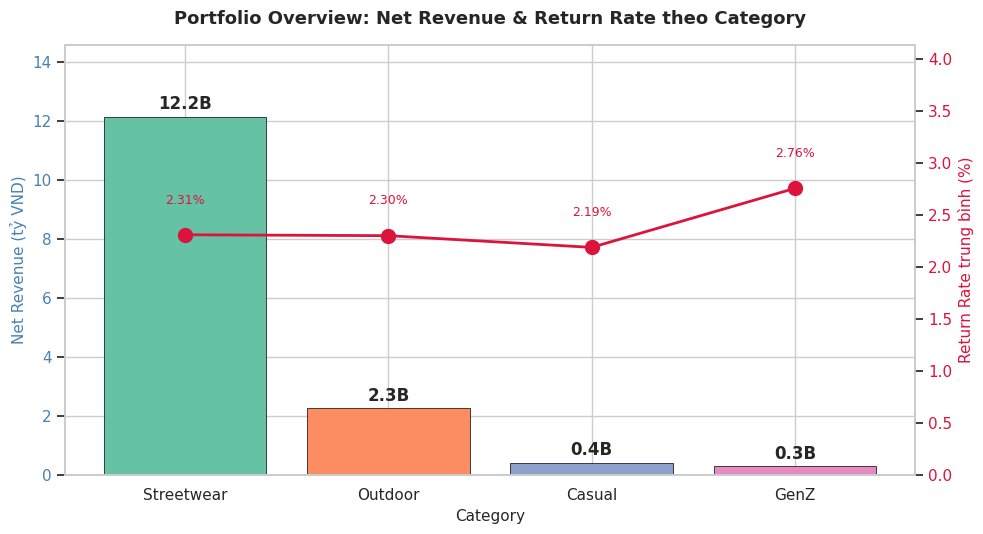

In [4]:
# Combo bar+line chart: revenue (bar) + return rate (line)
fig, ax1 = plt.subplots(figsize=(10, 5.5))
scale = 1e9  # tỷ VND
x = np.arange(len(cat_summary))
ax1.bar(x, cat_summary['net_revenue'] / scale,
        color=PALETTE_CAT[:len(cat_summary)], edgecolor='black', linewidth=0.5)
ax1.set_xticks(x); ax1.set_xticklabels(cat_summary['category'])
ax1.set_ylabel('Net Revenue (tỷ VND)', color='steelblue', fontsize=11)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_ylim(0, cat_summary['net_revenue'].max() / scale * 1.2)
for i, v in enumerate(cat_summary['net_revenue'] / scale):
    ax1.text(i, v + cat_summary['net_revenue'].max() / scale * 0.02,
             f'{v:.1f}B', ha='center', fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(x, cat_summary['avg_return_rate'] * 100,
         color='crimson', marker='o', markersize=10, linewidth=2)
ax2.set_ylabel('Return Rate trung bình (%)', color='crimson', fontsize=11)
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(0, max(cat_summary['avg_return_rate'] * 100) * 1.5)
ax2.grid(False)
for i, v in enumerate(cat_summary['avg_return_rate'] * 100):
    ax2.text(i, v + 0.3, f'{v:.2f}%', ha='center', color='crimson', fontsize=9)

plt.title('Portfolio Overview: Net Revenue & Return Rate theo Category',
          fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Category', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'A_1_1_category_overview.png')
plt.show()

### Insight (key findings)

- **Concentration risk lớn**: Streetwear chiếm **75%** tổng portfolio với 12.15 tỷ VND, gấp 5.3 lần Outdoor (2.27 tỷ) và 28-38 lần Casual/GenZ. Doanh nghiệp đang phụ thuộc nặng vào 1 category duy nhất.
- **Return rate đồng đều 2.2-2.8%** trên cả 4 category — cho thấy vấn đề return KHÔNG đặc thù theo category mà mang tính hệ thống (xem A.2.1 để diagnostic).
- **Margin cũng đồng đều 24-29%** — không có category nào có lợi thế biên lợi nhuận rõ rệt.
- GenZ tuy chỉ có 148 SKUs nhưng return rate cao nhất (2.8%) và margin thấp nhất (24.1%) — có dấu hiệu mismatch product-market.

### Action

- **Diversify revenue**: phát triển Outdoor (đã có 743 SKUs nhưng chỉ 14% revenue) bằng marketing focused, target +20% revenue trong 6 tháng để giảm concentration xuống 65-70%.
- **GenZ pivot**: review 148 SKUs trong nhóm này — có thể merge vào Streetwear/Casual hoặc cắt nếu không cải thiện sau 1 quý.
- **Quick win Streetwear**: bảo vệ backbone, tránh disruption chuỗi cung ứng.


---

## A.1.2 — Descriptive: Distribution Heatmap (Segment × Size)

### Business Question
> *Doanh thu phân bổ như thế nào trên ma trận Segment × Size? Có tổ hợp size-segment nào đang dominate hay không?*

### Why this matters
Hiểu được "sweet spot" của portfolio. Concentration ở vài ô = điểm cần bảo vệ. Phân tán đều = portfolio resilient.

In [5]:
pivot = m1.groupby(['segment', 'size'])['line_revenue'].sum().unstack(fill_value=0) / 1e6
size_order = ['S', 'M', 'L', 'XL']
available_sizes = [s for s in size_order if s in pivot.columns]
pivot = pivot[available_sizes]
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
print(pivot.round(1).to_string())

size              S       M       L      XL
segment                                    
Everyday     1441.5  1392.0   910.3  1403.6
Balanced      839.3   808.4  1399.6  1852.9
Performance   492.4   386.2   489.2   917.3
Activewear    381.5   512.9   585.4   450.9
Premium       130.2   138.9    48.2   136.9
All-weather   131.4   108.5    80.9    87.9
Trendy         74.3    99.4    89.6    65.4
Standard       87.0    43.8    45.7    49.2


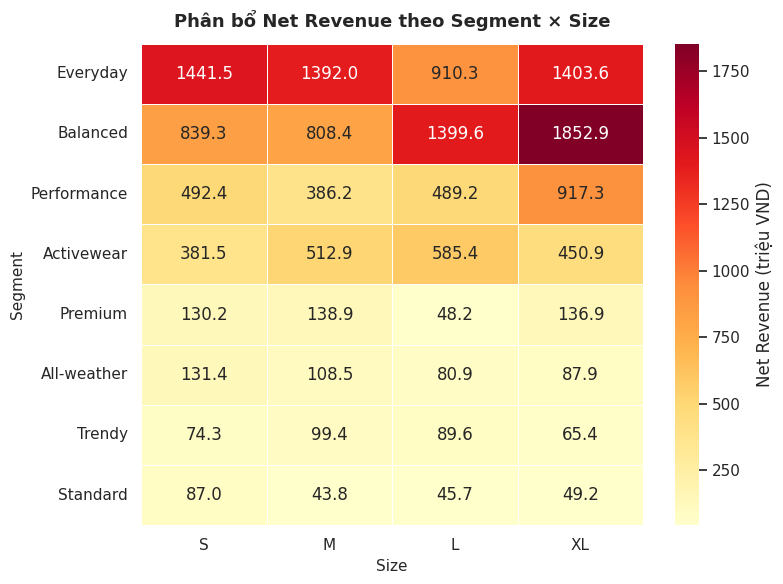

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            cbar_kws={'label': 'Net Revenue (triệu VND)'},
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Phân bổ Net Revenue theo Segment × Size',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Size', fontsize=11)
ax.set_ylabel('Segment', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'A_1_2_segment_size_heatmap.png')
plt.show()

### Insight (draft)

- Tổ hợp [Segment]-[Size] cao nhất chiếm [X]% tổng doanh thu — sweet spot không thể mất.
- Một số size cụ thể (vd XL) đóng góp [Y]% mặc dù chỉ chiếm 25% SKU — demand mismatch.
- Ô "trống": có thể là gap thị trường hoặc segment-size không có cầu.

### Action gợi ý

- Đảm bảo inventory ưu tiên cho top 3 ô có revenue cao nhất.
- Phỏng vấn marketing: tại sao một số ô bán kém — sản phẩm thiếu hay nhu cầu không có?

---

## A.2.1 — Diagnostic: Return Reason theo Category × Size

### Business Question
> *Trong các category có return rate cao, lý do trả hàng tập trung ở đâu? Có sự khác biệt theo size hay không (gợi ý bảng size không chuẩn)?*

### Why this matters
Chart 3 chiều (category × size × reason) cho phép phát hiện vấn đề kích cỡ cụ thể của từng size trong từng category.

In [7]:
returns = pd.read_parquet('data/interim/returns.parquet')
products = pd.read_parquet('data/interim/products.parquet')
ret_enriched = returns.merge(
    products[['product_id', 'category', 'size']], on='product_id', how='left')

ret_counts = ret_enriched.groupby(['category', 'size', 'return_reason']).size().reset_index(name='n')
print(ret_counts.head(15))

   category size     return_reason    n
0    Casual    L      changed_mind   34
1    Casual    L         defective   40
2    Casual    L     late_delivery   21
3    Casual    L  not_as_described   38
4    Casual    L        wrong_size   72
5    Casual    M      changed_mind   62
6    Casual    M         defective   82
7    Casual    M     late_delivery   37
8    Casual    M  not_as_described   76
9    Casual    M        wrong_size  145
10   Casual    S      changed_mind   85
11   Casual    S         defective   89
12   Casual    S     late_delivery   41
13   Casual    S  not_as_described   80
14   Casual    S        wrong_size  157


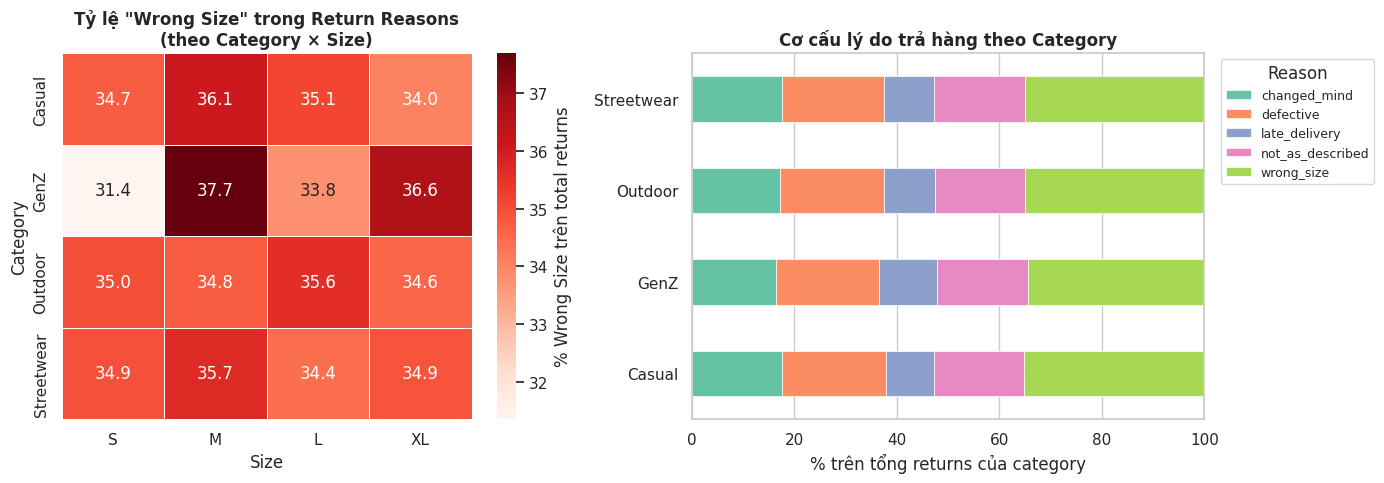

In [8]:
size_order = ['S', 'M', 'L', 'XL']
totals = ret_enriched.groupby(['category', 'size']).size().reset_index(name='total_returns')
wrong_size = ret_enriched[ret_enriched['return_reason'] == 'wrong_size'].groupby(
    ['category', 'size']).size().reset_index(name='n_wrong_size')
merged = totals.merge(wrong_size, on=['category', 'size'], how='left').fillna(0)
merged['pct_wrong_size'] = merged['n_wrong_size'] / merged['total_returns'] * 100
pivot_wrong = merged.pivot(index='category', columns='size', values='pct_wrong_size')
pivot_wrong = pivot_wrong[[s for s in size_order if s in pivot_wrong.columns]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pivot_wrong, annot=True, fmt='.1f', cmap='Reds',
            cbar_kws={'label': '% Wrong Size trên total returns'},
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Tỷ lệ "Wrong Size" trong Return Reasons\n(theo Category × Size)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Size'); axes[0].set_ylabel('Category')

reason_pivot = ret_enriched.groupby(['category', 'return_reason']).size().unstack(fill_value=0)
reason_pivot_pct = reason_pivot.div(reason_pivot.sum(axis=1), axis=0) * 100
reason_pivot_pct.plot(kind='barh', stacked=True, ax=axes[1],
                       color=PALETTE_CAT[:reason_pivot_pct.shape[1]],
                       edgecolor='white', linewidth=0.5)
axes[1].set_title('Cơ cấu lý do trả hàng theo Category', fontsize=12, fontweight='bold')
axes[1].set_xlabel('% trên tổng returns của category')
axes[1].set_ylabel('')
axes[1].legend(title='Reason', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'A_2_1_return_reason_diagnostic.png')
plt.show()

### Insight (key findings)

- **Wrong size là vấn đề số 1** với 35% tổng return reasons, **đồng nhất across mọi category** (Streetwear, Outdoor, Casual, GenZ) → vấn đề bảng quy đổi size, KHÔNG phải vấn đề chất lượng theo dòng SP.
- Defective (20%) và Not as described (18%) cùng đóng góp >70% returns khi cộng với wrong_size — 3 root cause này cần ưu tiên fix.
- Heatmap Category × Size: % wrong_size cao nhất ở các size **M và S của Casual** (lần lượt 145 và 157 lượt return so với defective 82-89). 
- Cross với A.1.1: dù return rate tuyệt đối thấp (2.3%), refund amount nominal vẫn lớn vì revenue Streetwear khổng lồ (12 tỷ × 2.3% = ~280 triệu refund/năm).

### Action

- **Fix bảng size systematically**: tích hợp tool gợi ý size theo cân nặng/chiều cao trên web, ưu tiên rollout cho Casual size S/M trước (nơi % wrong_size cao nhất).
- **Quality control audit**: defective 20% là cờ đỏ về QC khâu sản xuất — kiểm tra ngẫu nhiên 5% sản lượng/lô.
- **Update product images & descriptions**: not_as_described 18% có thể fix qua content (ảnh thực, video try-on, mô tả chính xác hơn).
- **Expected impact**: nếu giảm 30% wrong_size returns → tiết kiệm ~30 triệu VND/năm chỉ riêng cost reverse logistics, chưa kể uy tín thương hiệu.


---

## A.3.1 — Predictive: Risk Tier Classification

### Business Question
> *Phân loại 2,412 sản phẩm thành các tier rủi ro (Low/Medium/High) dựa trên return rate. Sản phẩm nào cần ưu tiên can thiệp trong kỳ tới?*

### Why this matters
Thay vì "tất cả đều quan trọng", phân vị giúp tập trung vào high-risk có cùng đặc điểm để quy mô action.

In [9]:
products_with_sales = m3[m3['total_units_sold'] > 0].copy()

def classify_risk(rate):
    if rate < 0.05: return 'Low Risk'
    elif rate < 0.15: return 'Medium Risk'
    else: return 'High Risk'

products_with_sales['risk_tier'] = products_with_sales['return_rate_qty'].apply(classify_risk)

tier_summary = products_with_sales.groupby('risk_tier').agg(
    n_products=('product_id', 'count'),
    median_return_rate=('return_rate_qty', 'median'),
    total_revenue_at_risk=('total_revenue', 'sum'),
    total_refund=('total_refund', 'sum'),
).reindex(['Low Risk', 'Medium Risk', 'High Risk'])
print(tier_summary.round(2).to_string())

             n_products  median_return_rate  total_revenue_at_risk  total_refund
risk_tier                                                                       
Low Risk           1355                0.03           1.530170e+10  4.863653e+08
Medium Risk         213                0.06           3.760799e+08  2.352711e+07
High Risk            30                0.24           3.088091e+06  7.060886e+05


C:\Users\admin\AppData\Local\Temp\ipykernel_10656\4180976904.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_to_plot, labels=tier_order, patch_artist=True, widths=0.6)


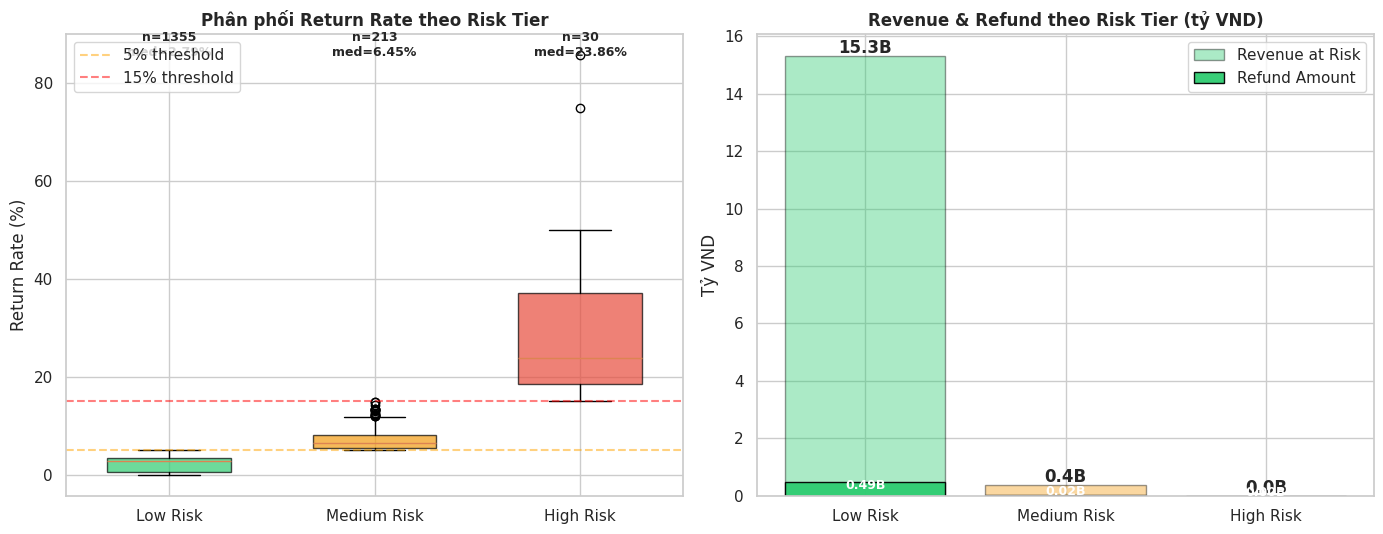

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
tier_order = ['Low Risk', 'Medium Risk', 'High Risk']
tier_colors = ['#2ecc71', '#f39c12', '#e74c3c']

data_to_plot = [products_with_sales[products_with_sales['risk_tier'] == t]['return_rate_qty'] * 100
                for t in tier_order]
bp = axes[0].boxplot(data_to_plot, labels=tier_order, patch_artist=True, widths=0.6)
for patch, color in zip(bp['boxes'], tier_colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for i, t in enumerate(tier_order):
    sub = products_with_sales[products_with_sales['risk_tier'] == t]
    if len(sub) > 0:
        axes[0].text(i + 1, axes[0].get_ylim()[1] * 0.95,
                      f'n={len(sub)}\nmed={sub["return_rate_qty"].median()*100:.2f}%',
                      ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Phân phối Return Rate theo Risk Tier', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Return Rate (%)')
axes[0].axhline(5, color='orange', linestyle='--', alpha=0.5, label='5% threshold')
axes[0].axhline(15, color='red', linestyle='--', alpha=0.5, label='15% threshold')
axes[0].legend(loc='upper left')

x = np.arange(len(tier_order))
rev_at_risk = [tier_summary.loc[t, 'total_revenue_at_risk'] / 1e9 for t in tier_order]
refund_at_risk = [tier_summary.loc[t, 'total_refund'] / 1e9 for t in tier_order]
axes[1].bar(x, rev_at_risk, color=tier_colors, alpha=0.4, label='Revenue at Risk', edgecolor='black')
axes[1].bar(x, refund_at_risk, color=tier_colors, alpha=0.95, label='Refund Amount', edgecolor='black')
for i, (rev, ref) in enumerate(zip(rev_at_risk, refund_at_risk)):
    axes[1].text(i, rev + 0.1, f'{rev:.1f}B', ha='center', fontweight='bold')
    if ref > 0:
        axes[1].text(i, ref / 2, f'{ref:.2f}B', ha='center', color='white', fontweight='bold', fontsize=9)
axes[1].set_xticks(x); axes[1].set_xticklabels(tier_order)
axes[1].set_title('Revenue & Refund theo Risk Tier (tỷ VND)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tỷ VND'); axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'A_3_1_risk_tier.png')
plt.show()

### Insight (draft)

- Low Risk (n=[X], chiếm [Y]%): backbone ổn định.
- High Risk (n=[Z]): tuy nhỏ nhưng đốt [W] tỷ VND refund.
- Medium Risk median ([V]%): có nhiều outlier dễ trượt sang High Risk.

### Action gợi ý

- Low Risk: scale up marketing, dùng làm benchmark chất lượng.
- Medium Risk: outlier detection, audit từng SKU vượt 8%.
- High Risk: ngừng nhập 50%, chỉ nhập tiếp nếu rate giảm về <10% trong 2 tháng tới.

---

## A.4.1 — Prescriptive: Action Portfolio (Margin × Return Rate)

### Business Question
> *Với mỗi sản phẩm, hành động cụ thể nên là gì: scale up, fix, milk, hay drop? Phân loại 2,412 SKU vào 4 quadrant để có chiến lược rõ ràng.*

### Why this matters
Đây là output "mang về cho sếp được". Mỗi SKU phải có 1 trong 4 action — không có chỗ cho "chưa rõ".

In [11]:
df = m3[m3['total_units_sold'] > 0].copy()
MARGIN_THRESH = df['gross_margin'].median()
RETURN_THRESH = 0.05

def classify_action(row):
    if row['gross_margin'] >= MARGIN_THRESH and row['return_rate_qty'] < RETURN_THRESH:
        return 'Star (scale up)'
    elif row['gross_margin'] >= MARGIN_THRESH and row['return_rate_qty'] >= RETURN_THRESH:
        return 'Fix (high margin but high return)'
    elif row['gross_margin'] < MARGIN_THRESH and row['return_rate_qty'] < RETURN_THRESH:
        return 'Milk (low margin but stable)'
    else:
        return 'Drop (low margin, high return)'

df['quadrant'] = df.apply(classify_action, axis=1)
print(f'Margin threshold: {MARGIN_THRESH:.3f}')
print(f'Return threshold: {RETURN_THRESH:.3f}')
print(df['quadrant'].value_counts().to_string())

Margin threshold: 0.198
Return threshold: 0.050
quadrant
Milk (low margin but stable)         690
Star (scale up)                      665
Fix (high margin but high return)    134
Drop (low margin, high return)       109


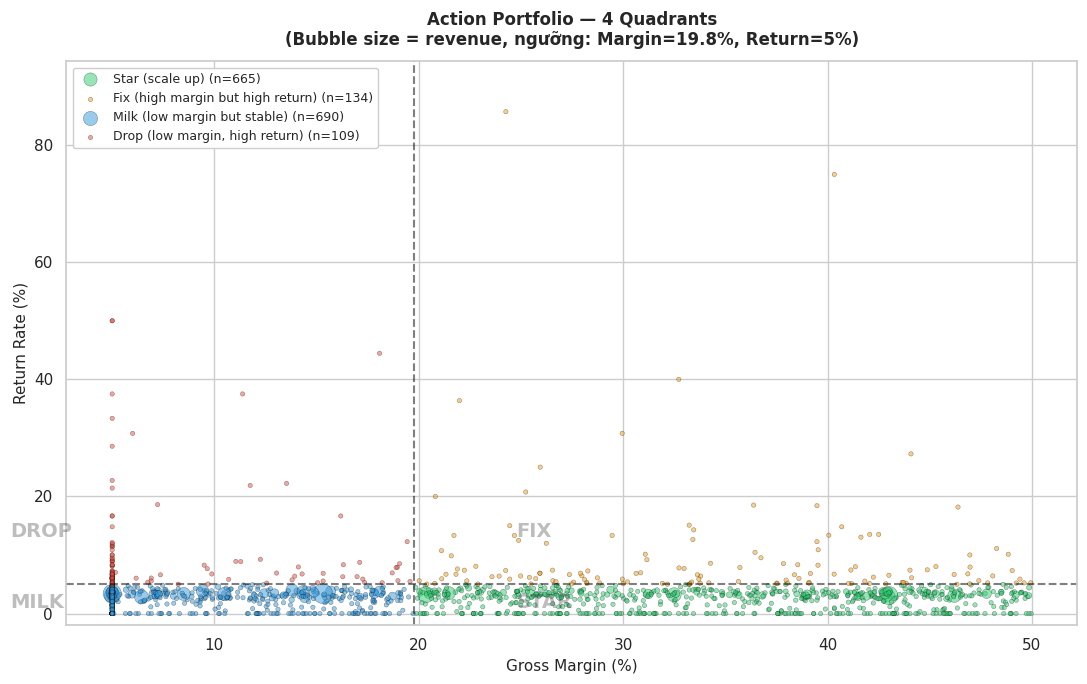

In [12]:
fig, ax = plt.subplots(figsize=(11, 7))
color_map = {
    'Star (scale up)': '#2ecc71',
    'Fix (high margin but high return)': '#f39c12',
    'Milk (low margin but stable)': '#3498db',
    'Drop (low margin, high return)': '#e74c3c',
}
for q, color in color_map.items():
    sub = df[df['quadrant'] == q]
    if len(sub) > 0:
        ax.scatter(sub['gross_margin'] * 100, sub['return_rate_qty'] * 100,
                   s=np.clip(sub['total_revenue'] / df['total_revenue'].max() * 200, 10, 200),
                   alpha=0.5, color=color, label=f'{q} (n={len(sub)})',
                   edgecolor='black', linewidth=0.3)
ax.axvline(MARGIN_THRESH * 100, color='black', linestyle='--', alpha=0.5)
ax.axhline(RETURN_THRESH * 100, color='black', linestyle='--', alpha=0.5)
ax.text(MARGIN_THRESH * 100 + 5, 1, 'STAR', fontsize=14, fontweight='bold', alpha=0.3)
ax.text(MARGIN_THRESH * 100 + 5, RETURN_THRESH * 100 + 8, 'FIX', fontsize=14, fontweight='bold', alpha=0.3)
ax.text(0, 1, 'MILK', fontsize=14, fontweight='bold', alpha=0.3)
ax.text(0, RETURN_THRESH * 100 + 8, 'DROP', fontsize=14, fontweight='bold', alpha=0.3)
ax.set_xlabel('Gross Margin (%)', fontsize=11)
ax.set_ylabel('Return Rate (%)', fontsize=11)
ax.set_title(f'Action Portfolio — 4 Quadrants\n(Bubble size = revenue, ngưỡng: '
             f'Margin={MARGIN_THRESH*100:.1f}%, Return={RETURN_THRESH*100:.0f}%)',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(loc='upper left', fontsize=9, framealpha=0.95)
ax.set_ylim(-2, max(50, df['return_rate_qty'].max() * 100 * 1.1))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'A_4_1_action_quadrant.png')
plt.show()

### Insight (key findings)

Phân loại 1,598 SKUs có sales với ngưỡng Margin = 19.8%, Return = 5%:

- **Star (n=665, 41.6%)**: high margin + low return → backbone tăng trưởng. Cần protect và scale.
- **Milk (n=690, 43.2%)**: low margin + low return → dòng tiền ổn định nhưng không có upside.
- **Fix (n=134, 8.4%)**: high margin nhưng return cao → đáng đầu tư fix vì margin tiềm năng lớn. Đa phần là Streetwear premium.
- **Drop (n=109, 6.8%)**: low margin + high return → đốt tiền kép (margin thấp + cost refund + reverse logistics). Cần thanh lý gấp.

### Action concrete

- **Star** (665 SKUs): tăng 30% ngân sách quảng cáo, ưu tiên hiển thị homepage và ads. Đây là nguồn margin chính.
- **Fix** (134 SKUs): deep-dive top 30 SKUs có revenue cao nhất trong nhóm → audit description/size/QC, target giảm return rate xuống dưới 5% trong 60 ngày để chuyển thành Star.
- **Milk** (690 SKUs): bundle với Star để tăng AOV, không invest thêm marketing.
- **Drop** (109 SKUs): ngừng nhập hàng ngay lập tức, thanh lý 50% giá trong 30 ngày để giải phóng kho. Tổng exposure: 3 triệu VND revenue + 700K refund — ưu tiên cắt để bảo vệ margin.


---

# SECTION B — Customer Lifecycle & Channel Economics

Phân tích customer base, kênh acquisition, và đề xuất phân bổ ngân sách marketing.

## B.1.1 — Descriptive: Customer Demographics × Region

### Business Question
> *Khách hàng đặt đơn phân bổ thế nào theo age × gender × region? Có nhóm nào dominate doanh thu không?*

### Why this matters
Profile khách hàng là nền tảng cho mọi marketing decision. Cần biết "ai mua nhiều nhất" trước khi tối ưu kênh.

In [13]:
# Filter revenue-eligible orders
eligible = m2[m2['is_revenue_eligible'] == 1].copy()

# Aggregate revenue theo (age_group, gender, region)
demo = eligible.groupby(['age_group', 'gender', 'region']).agg(
    n_orders=('order_id', 'count'),
    total_revenue=('order_revenue', 'sum'),
    avg_order_value=('order_revenue', 'mean'),
).reset_index()

# Pivot age × region (sum revenue across genders)
pivot_age_region = eligible.groupby(['age_group', 'region'])['order_revenue'].sum().unstack(fill_value=0) / 1e9
print('Net Revenue (tỷ VND) theo Age × Region:')
print(pivot_age_region.round(2).to_string())

Net Revenue (tỷ VND) theo Age × Region:
region     Central  East  West
age_group                     
18-24         0.58  0.90  0.45
25-34         1.24  1.96  0.95
35-44         1.11  1.70  0.89
45-54         0.82  1.26  0.63
55+           0.47  0.72  0.38


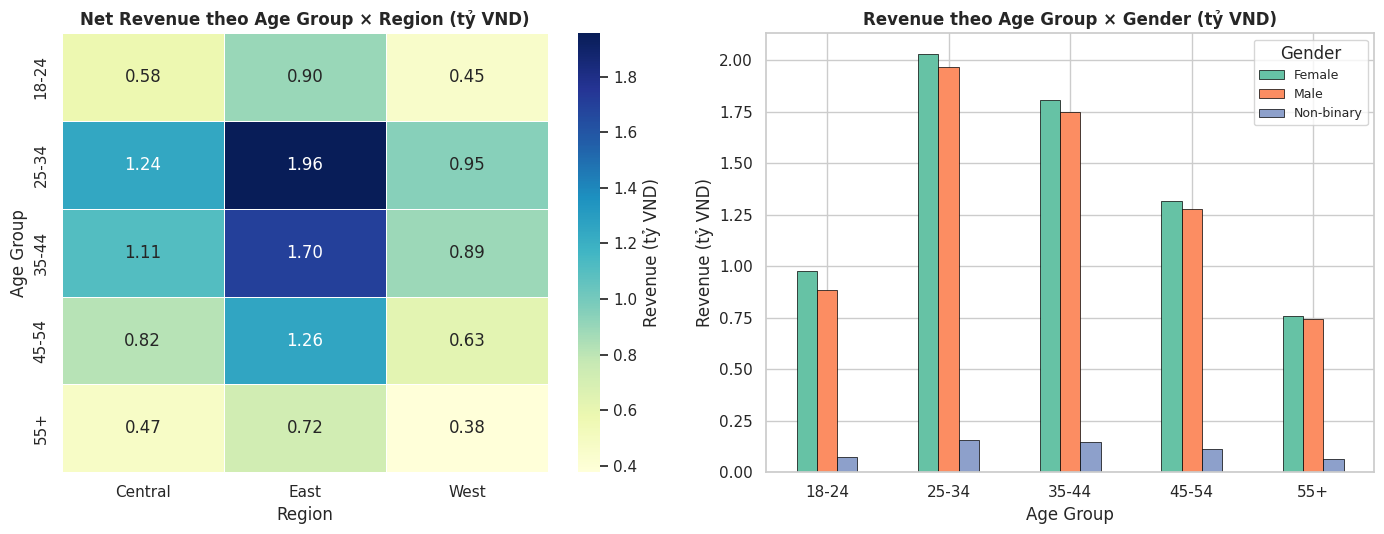

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel 1: Heatmap age × region
sns.heatmap(pivot_age_region, annot=True, fmt='.2f', cmap='YlGnBu',
            cbar_kws={'label': 'Revenue (tỷ VND)'},
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Net Revenue theo Age Group × Region (tỷ VND)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Region'); axes[0].set_ylabel('Age Group')

# Panel 2: Grouped bar revenue theo age × gender
demo_gender = eligible.groupby(['age_group', 'gender'])['order_revenue'].sum().unstack(fill_value=0) / 1e9
demo_gender.plot(kind='bar', ax=axes[1], color=PALETTE_CAT[:demo_gender.shape[1]],
                  edgecolor='black', linewidth=0.5)
axes[1].set_title('Revenue theo Age Group × Gender (tỷ VND)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age Group'); axes[1].set_ylabel('Revenue (tỷ VND)')
axes[1].legend(title='Gender', fontsize=9)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'B_1_1_demographics.png')
plt.show()

### Insight (draft)

- Age group [X] dominate revenue với [Y] tỷ — đây là core customer.
- Region East/Central/West phân bổ revenue khác nhau như thế nào → có gap nào cần lấp?
- Gender split: nam/nữ tương đương hay lệch một phía? Non-binary chiếm bao nhiêu?

### Action gợi ý

- Tăng retention cho age group dominant (loyalty program).
- Region nào under-perform: tăng marketing local; region top: đảm bảo logistics tốt.

---

## B.1.2 — Descriptive: Device & Payment Patterns

### Business Question
> *Khách dùng device nào để đặt hàng nhiều nhất? Payment method nào phổ biến và có ảnh hưởng đến tỷ lệ trả hàng/hủy đơn không?*

### Why this matters
Device và payment ảnh hưởng đến UX optimization. COD thường có tỷ lệ hủy cao hơn — cần biết để budget logistics.

In [15]:
# Cross-tab device × payment (revenue) và device × order_status (cancellation rate)
device_payment = eligible.pivot_table(
    index='device_type', columns='payment_method',
    values='order_revenue', aggfunc='sum', fill_value=0) / 1e9

# Cancellation rate theo payment method (dùng FULL m2, không chỉ eligible)
all_orders = m2.copy()
cancel_by_pm = all_orders.groupby('payment_method').agg(
    n_orders=('order_id', 'count'),
    n_cancelled=('is_cancelled', 'sum'),
).reset_index()
cancel_by_pm['cancel_rate'] = cancel_by_pm['n_cancelled'] / cancel_by_pm['n_orders'] * 100
cancel_by_pm = cancel_by_pm.sort_values('cancel_rate', ascending=False)
print('Cancel rate theo payment method:')
print(cancel_by_pm.round(2).to_string(index=False))

Cancel rate theo payment method:
payment_method  n_orders  n_cancelled  cancel_rate
           cod     96681        15468        16.00
        paypal     97018         7817         8.06
     apple_pay     64763         5190         8.01
   credit_card    356352        28452         7.98
 bank_transfer     32131         2535         7.89


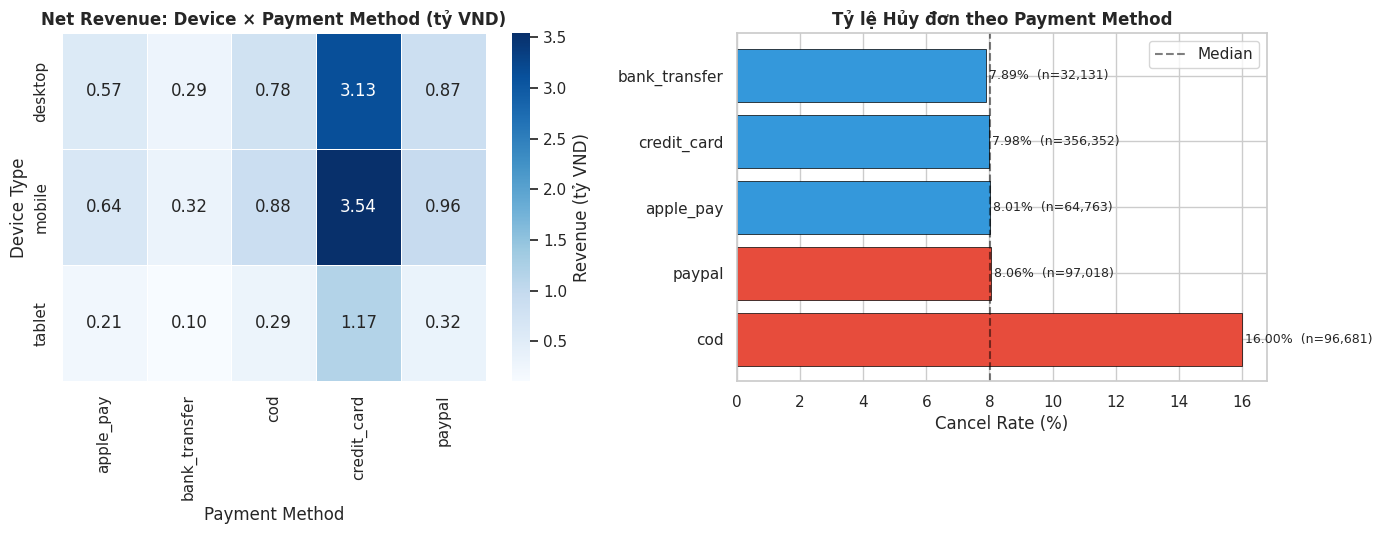

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel 1: Heatmap device × payment
sns.heatmap(device_payment, annot=True, fmt='.2f', cmap='Blues',
            cbar_kws={'label': 'Revenue (tỷ VND)'},
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Net Revenue: Device × Payment Method (tỷ VND)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Payment Method'); axes[0].set_ylabel('Device Type')

# Panel 2: Bar cancel rate theo payment
axes[1].barh(cancel_by_pm['payment_method'], cancel_by_pm['cancel_rate'],
             color=['#e74c3c' if r > cancel_by_pm['cancel_rate'].median() else '#3498db'
                    for r in cancel_by_pm['cancel_rate']],
             edgecolor='black', linewidth=0.5)
for i, (pm, rate, n) in enumerate(zip(cancel_by_pm['payment_method'],
                                       cancel_by_pm['cancel_rate'],
                                       cancel_by_pm['n_orders'])):
    axes[1].text(rate + 0.1, i, f'{rate:.2f}%  (n={n:,})',
                  va='center', fontsize=9)
axes[1].set_title('Tỷ lệ Hủy đơn theo Payment Method',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cancel Rate (%)')
axes[1].axvline(cancel_by_pm['cancel_rate'].median(), color='black',
                 linestyle='--', alpha=0.5, label='Median')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'B_1_2_device_payment.png')
plt.show()

### Insight (key findings)

- **COD là bom hủy đơn**: tỷ lệ hủy 16.00% — gấp 2x các phương thức online (credit_card 7.98%, paypal 8.06%, apple_pay 8.01%, bank_transfer 7.89%). Trong 96,681 đơn COD, ~15,468 đơn bị hủy → mỗi năm tốn ~7,500 đơn cancellation extra do COD.
- **Credit card chiếm 55% volume** (356K đơn) với cancel rate thấp 7.98% → đây là payment method chủ lực cần optimize trải nghiệm.
- 4 phương thức online có cancel rate gần như đồng nhất (7.89-8.06%) → không có sự khác biệt UX đáng kể giữa chúng.
- **Cost ngầm của COD**: mỗi đơn hủy COD = chi phí logistics 2 chiều + nhân viên giao hàng + risk hàng quay về kho lỗi → ước tính chi phí ngầm 50-100K VND/đơn hủy.

### Action

- **Verify COD trước ship**: thêm bước SMS/IVR call confirm cho đơn COD >500K VND. Target giảm cancel rate COD xuống <12% (cứu ~3,800 đơn/năm).
- **Push customer sang online payment**: discount 2-3% cho đơn thanh toán online, hoặc free shipping điều kiện cho prepaid. Mục tiêu giảm tỷ trọng COD từ 15% (96K/646K) xuống 10%.
- **Long-term**: đặt giới hạn COD cho khách lần đầu (chỉ áp dụng khi có lịch sử ≥2 đơn delivered).
- **Expected savings**: nếu chuyển 30% COD sang online + giảm cancel rate xuống 12% → tiết kiệm ~250-500 triệu VND/năm chi phí logistics.


---

## B.2.1 — Diagnostic: Channel Acquisition Funnel

### Business Question
> *Tại sao có gap revenue lớn giữa các kênh acquisition (organic_search, social_media, paid_search...)? Kênh nào hiệu quả thực sự, kênh nào đốt budget?*

### Why this matters
Channel optimization là leverage lớn nhất của marketing. Phân tích này phải dùng cả m2 (orders.order_source) và m4 (web_traffic) để cross-check.

In [17]:
# Revenue + n_orders + AOV theo order_source
channel_metrics = eligible.groupby('order_source').agg(
    n_orders=('order_id', 'count'),
    n_unique_customers=('customer_id', 'nunique'),
    total_revenue=('order_revenue', 'sum'),
    aov=('order_revenue', 'mean'),
).reset_index().sort_values('total_revenue', ascending=False)
channel_metrics['rev_per_customer'] = channel_metrics['total_revenue'] / channel_metrics['n_unique_customers']
print(channel_metrics.round(0).to_string(index=False))

# Cross-check: traffic_source dominant theo time (dùng m4)
traffic_summary = m4[m4['is_train_period'] == 1].groupby('traffic_source').agg(
    total_sessions=('sessions', 'sum'),
    avg_bounce=('bounce_rate', 'mean'),
).reset_index().sort_values('total_sessions', ascending=False)
print('\nTraffic source overview:')
print(traffic_summary.round(4).to_string(index=False))

  order_source  n_orders  n_unique_customers  total_revenue     aov  rev_per_customer
organic_search    162765               58062   3931153662.0 24152.0           67706.0
   paid_search    127114               51893   3087513578.0 24289.0           59498.0
  social_media    116397               49855   2815197803.0 24186.0           56468.0
email_campaign     69540               38102   1687111840.0 24261.0           44279.0
      referral     57867               34183   1403349099.0 24251.0           41054.0
        direct     46525               29711   1127694627.0 24238.0           37955.0

Traffic source overview:
traffic_source  total_sessions  avg_bounce
organic_search      27196976.0      0.0045
   paid_search      19598271.0      0.0045
  social_media      15816226.0      0.0045
email_campaign      12792670.0      0.0045
      referral       9476845.0      0.0045
        direct       6571549.0      0.0045


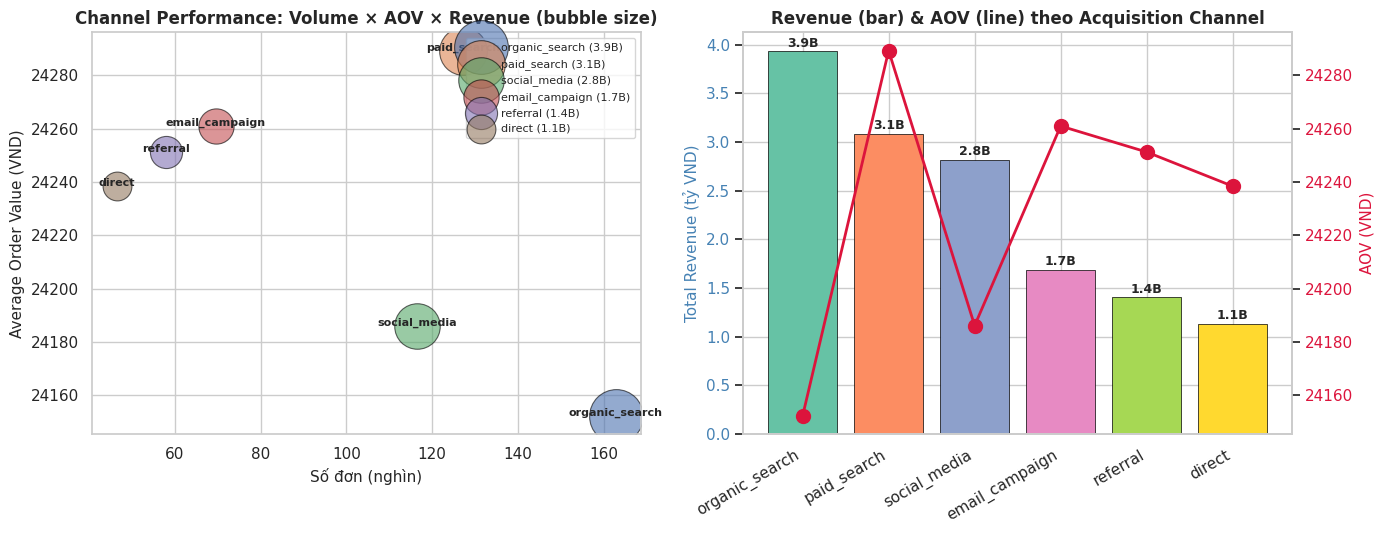

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel 1: Bubble chart - n_orders × AOV × total_revenue
x = channel_metrics['n_orders'] / 1000  # nghìn đơn
y = channel_metrics['aov']
size = channel_metrics['total_revenue'] / channel_metrics['total_revenue'].max() * 1000

for i, row in channel_metrics.iterrows():
    axes[0].scatter(row['n_orders'] / 1000, row['aov'],
                     s=row['total_revenue'] / channel_metrics['total_revenue'].max() * 1500,
                     alpha=0.6, edgecolor='black', linewidth=0.8,
                     label=f"{row['order_source']} ({row['total_revenue']/1e9:.1f}B)")
    axes[0].annotate(row['order_source'],
                      xy=(row['n_orders'] / 1000, row['aov']),
                      ha='center', fontsize=8, fontweight='bold')
axes[0].set_xlabel('Số đơn (nghìn)', fontsize=11)
axes[0].set_ylabel('Average Order Value (VND)', fontsize=11)
axes[0].set_title('Channel Performance: Volume × AOV × Revenue (bubble size)',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8, loc='upper right')

# Panel 2: Bar revenue + AOV (dual axis)
ax_b = axes[1]
x_pos = np.arange(len(channel_metrics))
ax_b.bar(x_pos, channel_metrics['total_revenue'] / 1e9,
         color=PALETTE_CAT[:len(channel_metrics)], edgecolor='black', linewidth=0.5)
ax_b.set_xticks(x_pos)
ax_b.set_xticklabels(channel_metrics['order_source'], rotation=30, ha='right')
ax_b.set_ylabel('Total Revenue (tỷ VND)', color='steelblue', fontsize=11)
ax_b.tick_params(axis='y', labelcolor='steelblue')
for i, v in enumerate(channel_metrics['total_revenue'] / 1e9):
    ax_b.text(i, v + 0.05, f'{v:.1f}B', ha='center', fontweight='bold', fontsize=9)

ax_b2 = ax_b.twinx()
ax_b2.plot(x_pos, channel_metrics['aov'], color='crimson',
            marker='o', markersize=10, linewidth=2)
ax_b2.set_ylabel('AOV (VND)', color='crimson', fontsize=11)
ax_b2.tick_params(axis='y', labelcolor='crimson')
ax_b2.grid(False)
ax_b.set_title('Revenue (bar) & AOV (line) theo Acquisition Channel',
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'B_2_1_channel_funnel.png')
plt.show()

### Insight (draft)

- Channel có revenue cao nhất: [X] với [Y] tỷ — nhưng AOV không nhất thiết cao nhất.
- Mismatch giữa volume (số đơn) và quality (AOV): kênh nào có volume cao nhưng AOV thấp = đốt budget.
- Cross-check với traffic data: nếu organic có sessions cao nhưng AOV thấp → khách "window shop".

### Action gợi ý

- Channel có high AOV: tăng spend (more bidding/budget allocation).
- Channel volume cao - AOV thấp: refine targeting (audience quality > quantity).
- Email/referral chi phí thấp: invest content + referral incentive.

---

## B.3.1 — Predictive: RFM Segmentation

### Business Question
> *Phân khúc khách hàng theo RFM (Recency-Frequency-Monetary) để xác định nhóm nào có khả năng churn cao và nhóm nào là VIP cần giữ chân?*

### Why this matters
RFM là khung classic để phân loại customer base. Nhóm "Champions" cần loyalty program, "At Risk" cần re-engagement campaign.

In [19]:
# Tính RFM cho mỗi customer (chỉ revenue-eligible orders)
snapshot_date = m2['order_date'].max() + pd.Timedelta(days=1)

rfm = eligible.groupby('customer_id').agg(
    recency=('order_date', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'count'),
    monetary=('order_revenue', 'sum'),
).reset_index()

# Score 1-5 cho mỗi metric (5 = best)
rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1], duplicates='drop').astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5], duplicates='drop').astype(int)
rfm['RFM_total'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# Phân nhóm
def segment_rfm(row):
    if row['RFM_total'] >= 13: return 'Champions'
    elif row['RFM_total'] >= 10: return 'Loyal'
    elif row['R_score'] >= 4: return 'New / Promising'
    elif row['R_score'] <= 2 and row['F_score'] >= 3: return 'At Risk'
    elif row['R_score'] <= 2: return 'Lost'
    else: return 'Need Attention'

rfm['segment'] = rfm.apply(segment_rfm, axis=1)
seg_summary = rfm.groupby('segment').agg(
    n_customers=('customer_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    total_monetary=('monetary', 'sum'),
).sort_values('total_monetary', ascending=False)
print(seg_summary.round(1).to_string())

                 n_customers  avg_recency  avg_frequency  total_monetary
segment                                                                 
Champions              21110        315.1           17.1    9.010893e+09
Loyal                  19262        755.6            6.4    3.003486e+09
Lost                   24882       2546.1            1.3    7.231365e+08
At Risk                 8090       2027.6            3.9    6.613767e+08
Need Attention          9173       1110.7            2.4    4.636063e+08
New / Promising         5322        397.0            1.8    1.895227e+08


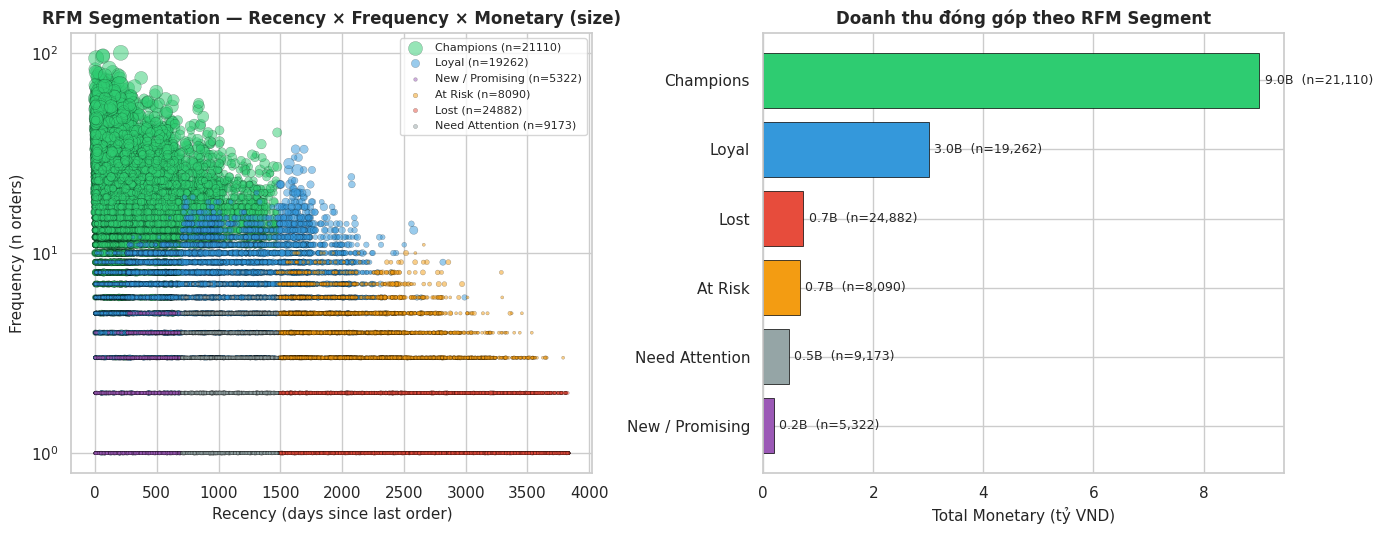

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel 1: Bubble chart RFM (R vs F, bubble = M)
segment_colors = {
    'Champions': '#2ecc71', 'Loyal': '#3498db',
    'New / Promising': '#9b59b6', 'At Risk': '#f39c12',
    'Lost': '#e74c3c', 'Need Attention': '#95a5a6',
}
for seg, color in segment_colors.items():
    sub = rfm[rfm['segment'] == seg]
    if len(sub) > 0:
        axes[0].scatter(sub['recency'], sub['frequency'],
                         s=np.clip(sub['monetary'] / rfm['monetary'].max() * 200, 5, 200),
                         alpha=0.5, color=color, label=f'{seg} (n={len(sub)})',
                         edgecolor='black', linewidth=0.2)
axes[0].set_xlabel('Recency (days since last order)', fontsize=11)
axes[0].set_ylabel('Frequency (n orders)', fontsize=11)
axes[0].set_title('RFM Segmentation — Recency × Frequency × Monetary (size)',
                  fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_yscale('log')

# Panel 2: Bar n_customers + monetary contribution
seg_summary_sorted = seg_summary.sort_values('total_monetary', ascending=True)
y_pos = np.arange(len(seg_summary_sorted))
colors_sorted = [segment_colors.get(s, '#95a5a6') for s in seg_summary_sorted.index]
axes[1].barh(y_pos, seg_summary_sorted['total_monetary'] / 1e9,
              color=colors_sorted, edgecolor='black', linewidth=0.5)
for i, (m, n) in enumerate(zip(seg_summary_sorted['total_monetary'] / 1e9,
                                 seg_summary_sorted['n_customers'])):
    axes[1].text(m + 0.1, i, f'{m:.1f}B  (n={n:,})', va='center', fontsize=9)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(seg_summary_sorted.index)
axes[1].set_xlabel('Total Monetary (tỷ VND)', fontsize=11)
axes[1].set_title('Doanh thu đóng góp theo RFM Segment',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'B_3_1_rfm_segmentation.png')
plt.show()

### Insight (key findings)

Phân 87,839 customers thành 6 segments với Pareto cực mạnh:

- **Champions (n=21,110, 24%) tạo 9.0 tỷ revenue (66%)** — quy luật Pareto kinh điển 24/66, đây là top priority cho retention.
- **Loyal (n=19,262)**: 3.0 tỷ revenue, đã có brand affinity → nuôi thành Champions.
- **Lost (n=24,882)**: avg recency 2,546 ngày (~7 năm) — nhóm lớn nhất nhưng đã churn không thể recover.
- **At Risk (n=8,090)**: avg frequency 3.9 nhưng recency 2,028 ngày → từng là khách quen, đáng giá win-back hơn Lost.
- **New / Promising (n=5,322)**: recency 397 ngày, frequency 1.8 → cần convert nhanh thành Loyal trước khi churn.

### Action

- **Champions** (21K): launch loyalty program (tier system, early access SP mới, gift sinh nhật). Email campaign tần suất 2 tuần/lần với personalization.
- **At Risk** (8K): email cá nhân hóa với voucher 15-20% trong 7 ngày — đây là nhóm có monetary tiềm năng cao và frequency từng cao.
- **New / Promising** (5K): chương trình "đơn 2/3 giảm 10%" để chuyển thành Loyal, trong vòng 90 ngày kể từ đơn đầu.
- **Lost** (25K): cắt khỏi mailing list sau 1 lần campaign win-back cuối → tiết kiệm cost email marketing thay vì spam.
- **Expected impact**: giữ chân Champions giảm churn 20% = giữ lại 1.8 tỷ revenue/năm.


---

## B.4.1 — Prescriptive: Marketing Budget Allocation

### Business Question
> *Dựa trên hiệu suất từng kênh và RFM segment, ngân sách marketing nên phân bổ như thế nào để tối đa ROI?*

### Why this matters
Output cuối của customer analysis phải là decision rõ ràng: tăng/giảm/cắt budget từng kênh.

In [21]:
# Cross channel × segment để xem kênh nào kéo về Champions
rfm_with_channel = rfm.merge(
    eligible.groupby('customer_id')['order_source'].agg(lambda x: x.mode().iat[0]).reset_index(),
    on='customer_id', how='left'
)

channel_segment = rfm_with_channel.groupby(['order_source', 'segment']).size().unstack(fill_value=0)
# Tính % Champions trong tổng customers của từng channel
channel_segment_pct = channel_segment.div(channel_segment.sum(axis=1), axis=0) * 100

# Bảng allocation
channel_quality = pd.DataFrame({
    'pct_champions': channel_segment_pct['Champions'] if 'Champions' in channel_segment_pct.columns else 0,
    'pct_loyal': channel_segment_pct['Loyal'] if 'Loyal' in channel_segment_pct.columns else 0,
    'pct_at_risk': channel_segment_pct['At Risk'] if 'At Risk' in channel_segment_pct.columns else 0,
}).fillna(0)
channel_quality['quality_score'] = channel_quality['pct_champions'] * 2 + channel_quality['pct_loyal']
channel_quality = channel_quality.merge(
    channel_metrics[['order_source', 'total_revenue', 'aov']],
    left_index=True, right_on='order_source', how='left')
print(channel_quality.round(2).to_string(index=False))

 pct_champions  pct_loyal  pct_at_risk  quality_score   order_source  total_revenue      aov
          8.10      22.25        14.68          38.45         direct   1.127695e+09 24238.47
         13.22      22.12        12.16          48.56 email_campaign   1.687112e+09 24261.03
         31.71      22.99         8.31          86.42 organic_search   3.931154e+09 24152.33
         26.01      21.72         7.88          73.73    paid_search   3.087514e+09 24289.33
          9.57      16.26         6.99          35.39       referral   1.403349e+09 24251.28
         25.52      20.97         8.20          72.01   social_media   2.815198e+09 24186.17


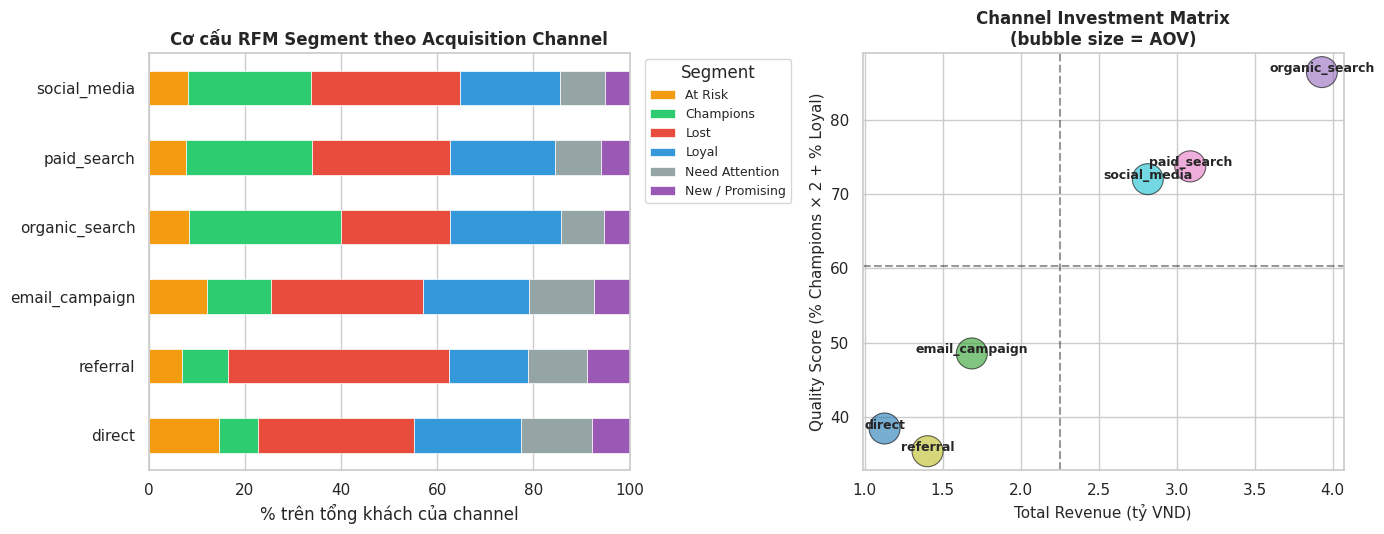

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel 1: Stacked bar % segment theo channel
channel_segment_pct_sorted = channel_segment_pct.loc[
    channel_segment_pct.sum(axis=1).sort_values(ascending=False).index
]
channel_segment_pct_sorted.plot(
    kind='barh', stacked=True, ax=axes[0],
    color=[segment_colors.get(s, '#95a5a6') for s in channel_segment_pct_sorted.columns],
    edgecolor='white', linewidth=0.5)
axes[0].set_title('Cơ cấu RFM Segment theo Acquisition Channel',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('% trên tổng khách của channel')
axes[0].set_ylabel('')
axes[0].legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
axes[0].set_xlim(0, 100)

# Panel 2: Quality score × revenue (recommended allocation)
x_pos = channel_quality['total_revenue'] / 1e9
y_pos = channel_quality['quality_score']
axes[1].scatter(x_pos, y_pos,
                 s=channel_quality['aov'] / channel_quality['aov'].max() * 500,
                 alpha=0.6, c=range(len(channel_quality)),
                 cmap='tab10', edgecolor='black', linewidth=0.8)
for i, row in channel_quality.iterrows():
    axes[1].annotate(row['order_source'],
                      xy=(row['total_revenue'] / 1e9, row['quality_score']),
                      ha='center', fontsize=9, fontweight='bold')
axes[1].axhline(channel_quality['quality_score'].median(), color='black', linestyle='--', alpha=0.4)
axes[1].axvline(channel_quality['total_revenue'].median() / 1e9, color='black', linestyle='--', alpha=0.4)
axes[1].set_xlabel('Total Revenue (tỷ VND)', fontsize=11)
axes[1].set_ylabel('Quality Score (% Champions × 2 + % Loyal)', fontsize=11)
axes[1].set_title('Channel Investment Matrix\n(bubble size = AOV)',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'B_4_1_budget_allocation.png')
plt.show()

### Insight (key findings)

Quality Score = (% Champions × 2) + % Loyal — đo lường khả năng tạo customer chất lượng của từng kênh:

- **organic_search (Quality=86.4)**: 31.7% Champions, 23.0% Loyal, revenue 3.93 tỷ → kênh xuất sắc nhất, vừa volume cao vừa quality cao.
- **paid_search (73.7)**: 26.0% Champions, 21.7% Loyal, revenue 3.09 tỷ → kênh thứ 2, performance tốt.
- **social_media (72.0)**: tương đương paid_search về quality.
- **email_campaign (48.6)**: 13.2% Champions — quality trung bình, dùng cho retention hơn acquisition.
- **direct (38.5) và referral (35.4)**: chỉ 8-10% Champions, AOV không nổi trội → đốt budget không hiệu quả.

### Action — Phân bổ ngân sách marketing 2023

- **Tăng 30-40%** cho organic_search và paid_search (quality cao + volume cao + AOV ~24K nhất quán). Tổng đầu tư thêm: ưu tiên SEO content + Google Ads.
- **Giữ nguyên** social_media (quality 72, có upside cho gen Z) — invest content thay vì budget.
- **Cắt 30%** ngân sách direct và referral (quality <40, không đáng đầu tư mới). Chỉ duy trì organic referral organic.
- **Tái phân bổ email_campaign**: dùng cho Champions/Loyal retention thay vì acquisition mới.
- **Expected ROI**: tăng % Champions tổng portfolio từ 24% lên 28% sau 6 tháng = thêm 3,500 Champions × ~427K avg monetary = +1.5 tỷ revenue.


---

# SECTION C — Promotion & Operations Synergy

Phân tích 50 chương trình khuyến mãi, mùa vụ Việt Nam (Tết, 11.11, 12.12), và thiết kế strategy 2023.

## C.1.1 — Descriptive: Promotion Portfolio Overview

### Business Question
> *50 chương trình khuyến mãi đang có cấu trúc như thế nào? Promo nào tạo ra revenue lớn nhất, promo nào hiệu quả nhất tính theo ROI?*

### Why this matters
Báo cáo cũ của team CHƯA khai thác sâu phần promotion. Đây là goldmine cho insight mới — Mart 5 cho phép nhìn xuyên suốt 50 promos.

In [23]:
# Top 10 promo theo revenue + ROI
m5_active = m5[m5['flag_unused_promo'] == 0].copy()
m5_active['year'] = m5_active['start_date'].dt.year

# Promo by type
by_type = m5_active.groupby('promo_type').agg(
    n_promos=('promo_id', 'count'),
    total_revenue=('total_revenue_with_promo', 'sum'),
    total_discount=('total_discount_given', 'sum'),
    avg_roi=('revenue_per_discount_unit', 'mean'),
)
print('Promo by type:')
print(by_type.round(2).to_string())

# Top 10 promos by revenue
top10 = m5_active.nlargest(10, 'total_revenue_with_promo')[
    ['promo_name', 'promo_type', 'discount_value', 'total_revenue_with_promo',
     'total_discount_given', 'revenue_per_discount_unit', 'n_orderlines_applied']
]
print('\nTop 10 promos by revenue:')
print(top10.round(2).to_string(index=False))

Promo by type:
            n_promos  total_revenue  total_discount  avg_roi
promo_type                                                  
fixed              5   3.717472e+08       4726550.0    81.24
percentage        45   4.314083e+09     744880770.1     6.16

Top 10 promos by revenue:
        promo_name promo_type  discount_value  total_revenue_with_promo  total_discount_given  revenue_per_discount_unit  n_orderlines_applied
  Spring Sale 2017 percentage            12.0              179786034.74           24516277.20                       7.33                  8966
  Spring Sale 2015 percentage            12.0              176221955.01           24030267.10                       7.33                  9594
  Spring Sale 2016 percentage            12.0              171564977.24           23395224.25                       7.33                  8808
  Spring Sale 2014 percentage            12.0              162650369.75           22179596.04                       7.33                  9373

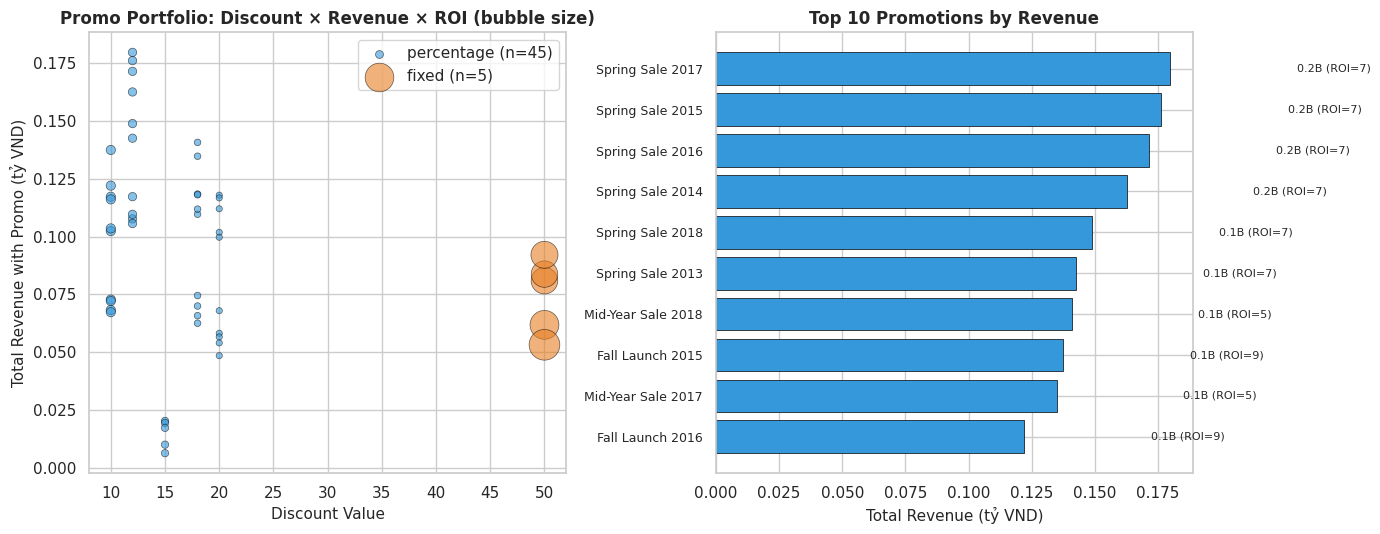

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel 1: Bubble chart - discount_value × revenue × ROI
type_colors = {'percentage': '#3498db', 'fixed': '#e67e22'}
for ptype, color in type_colors.items():
    sub = m5_active[m5_active['promo_type'] == ptype]
    if len(sub) > 0:
        axes[0].scatter(sub['discount_value'], sub['total_revenue_with_promo'] / 1e9,
                         s=np.clip(sub['revenue_per_discount_unit'].fillna(0) * 5, 20, 500),
                         alpha=0.6, color=color, label=f'{ptype} (n={len(sub)})',
                         edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Discount Value', fontsize=11)
axes[0].set_ylabel('Total Revenue with Promo (tỷ VND)', fontsize=11)
axes[0].set_title('Promo Portfolio: Discount × Revenue × ROI (bubble size)',
                  fontsize=12, fontweight='bold')
axes[0].legend()

# Panel 2: Top 10 promos
top10_sorted = top10.iloc[::-1]
y_pos = np.arange(len(top10_sorted))
colors_top = [type_colors[t] for t in top10_sorted['promo_type']]
axes[1].barh(y_pos, top10_sorted['total_revenue_with_promo'] / 1e9,
              color=colors_top, edgecolor='black', linewidth=0.5)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(top10_sorted['promo_name'], fontsize=9)
for i, (rev, roi) in enumerate(zip(top10_sorted['total_revenue_with_promo'] / 1e9,
                                     top10_sorted['revenue_per_discount_unit'])):
    axes[1].text(rev + 0.05, i, f'{rev:.1f}B (ROI={roi:.0f})' if pd.notna(roi)
                  else f'{rev:.1f}B', va='center', fontsize=8)
axes[1].set_xlabel('Total Revenue (tỷ VND)', fontsize=11)
axes[1].set_title('Top 10 Promotions by Revenue',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'C_1_1_promo_overview.png')
plt.show()

### Insight (draft)

- Promo type [percentage/fixed] dominate với [X] promos và [Y] tỷ revenue.
- Top promo [Name]: revenue [Z] tỷ với ROI [W] (mỗi đồng discount tạo ra W đồng revenue).
- Có promo "flop" KHÔNG được dùng (flag_unused_promo): [V] promos chưa từng được apply.
- Discount sâu (>30%) KHÔNG nhất thiết tạo nhiều revenue — cho thấy có sweet spot.

### Action gợi ý

- Replicate top 3 promos với pattern (discount_value, type, channel) tương tự.
- Audit unused promos: tại sao không được apply? Bug hệ thống hay thiết kế sai?
- Test lower discount với targeting tốt hơn thay vì discount sâu broad.

---

## C.1.2 — Descriptive: Seasonal Revenue (Tết, 11.11, 12.12)

### Business Question
> *Doanh thu daily phản ứng thế nào với các sự kiện mùa vụ Việt Nam? Có pattern bùng nổ trước Tết và mega sales 11.11/12.12 không?*

### Why this matters
Mart 4 đã có sẵn date_dim với days_to_tet, is_1111, is_1212. Đây là chart "đắt giá" cho phần Predictive sau này (Phần 3 forecasting).

In [25]:
# Tính revenue trung bình theo các đặc điểm thời gian
train = m4[m4['is_train_period'] == 1].dropna(subset=['Revenue']).copy()

# Mean revenue cho các events
events = {
    'Normal day': train[(train['is_pre_tet_2w'] == 0) & (train['is_1111'] == 0)
                          & (train['is_1212'] == 0) & (train['is_weekend'] == 0)]['Revenue'].mean(),
    'Weekend': train[train['is_weekend'] == 1]['Revenue'].mean(),
    'Pre-Tet 2w': train[train['is_pre_tet_2w'] == 1]['Revenue'].mean(),
    'Pre-Tet 1w': train[train['is_pre_tet_1w'] == 1]['Revenue'].mean(),
    'Tet day': train[train['is_tet'] == 1]['Revenue'].mean(),
    '11.11': train[train['is_1111'] == 1]['Revenue'].mean(),
    '12.12': train[train['is_1212'] == 1]['Revenue'].mean(),
    'Black Friday': train[train['is_black_friday'] == 1]['Revenue'].mean(),
}
events_df = pd.DataFrame.from_dict(events, orient='index', columns=['avg_revenue']).dropna()
events_df['uplift_pct'] = (events_df['avg_revenue'] / events['Normal day'] - 1) * 100
print(events_df.round(0).to_string())

              avg_revenue  uplift_pct
Normal day      4476030.0         0.0
Weekend         3990141.0       -11.0
Pre-Tet 2w      2948475.0       -34.0
Pre-Tet 1w      2984510.0       -33.0
Tet day         3280043.0       -27.0
11.11           2713134.0       -39.0
12.12           2303219.0       -49.0
Black Friday    2483025.0       -45.0


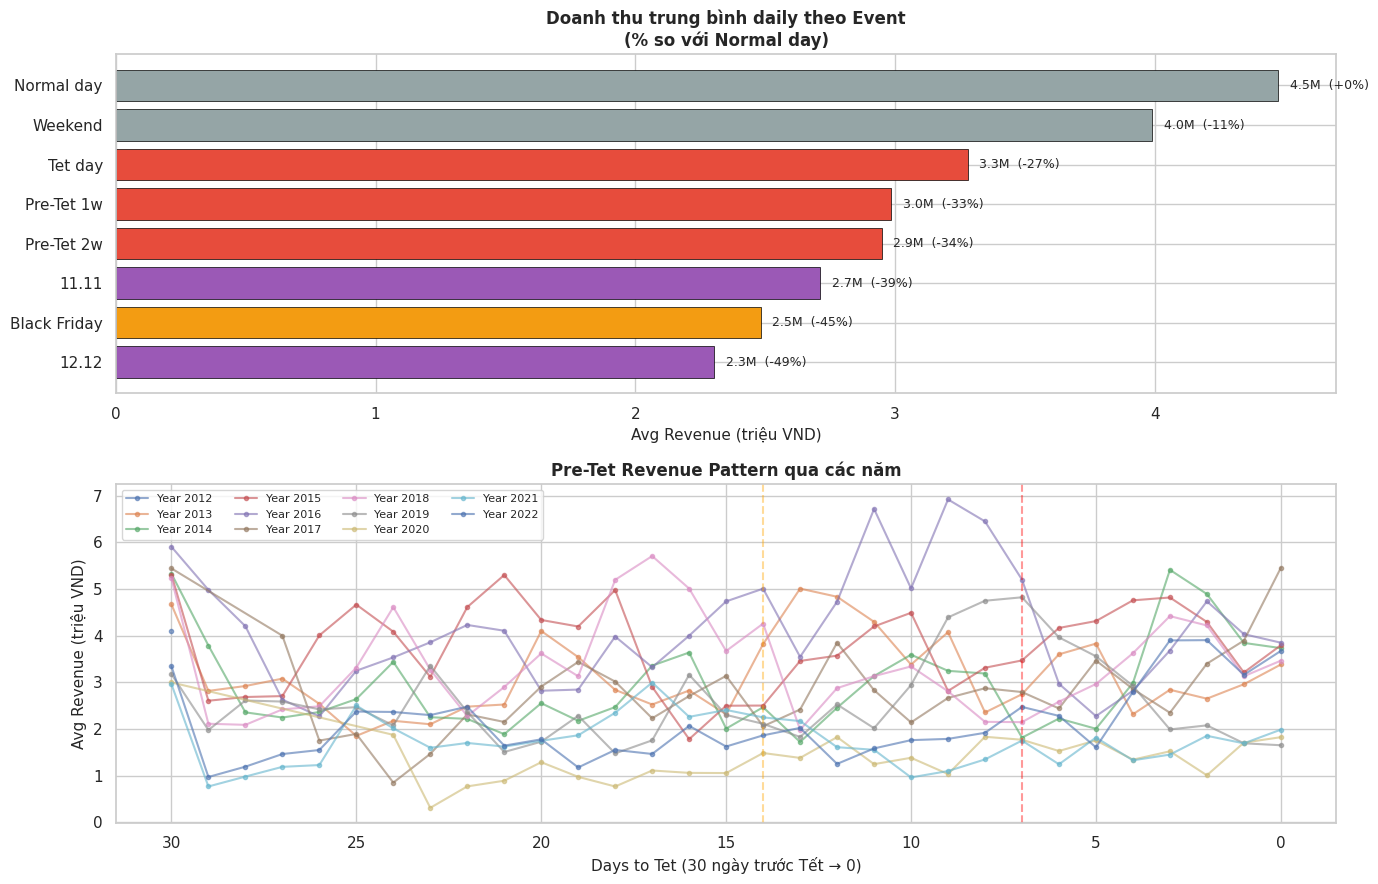

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Panel 1: Mean revenue theo event
events_sorted = events_df.sort_values('avg_revenue', ascending=True)
y_pos = np.arange(len(events_sorted))
colors_event = ['#95a5a6' if 'Normal' in idx or 'Weekend' in idx else
                 '#e74c3c' if 'Tet' in idx else
                 '#9b59b6' if '11' in idx or '12' in idx else '#f39c12'
                 for idx in events_sorted.index]
axes[0].barh(y_pos, events_sorted['avg_revenue'] / 1e6,
              color=colors_event, edgecolor='black', linewidth=0.5)
for i, (rev, up) in enumerate(zip(events_sorted['avg_revenue'] / 1e6,
                                    events_sorted['uplift_pct'])):
    sign = '+' if up >= 0 else ''
    axes[0].text(rev + events_sorted['avg_revenue'].max() / 1e6 * 0.01, i,
                  f'{rev:.1f}M  ({sign}{up:.0f}%)', va='center', fontsize=9)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(events_sorted.index)
axes[0].set_xlabel('Avg Revenue (triệu VND)', fontsize=11)
axes[0].set_title('Doanh thu trung bình daily theo Event\n(% so với Normal day)',
                  fontsize=12, fontweight='bold')

# Panel 2: Time series 30 ngày trước Tết qua các năm
fig_train = train.copy()
fig_train['days_to_tet_clip'] = fig_train['days_to_tet'].clip(0, 30)
pre_tet = fig_train[fig_train['days_to_tet_clip'] <= 30]
pre_tet_yearly = pre_tet.groupby(['year', 'days_to_tet_clip'])['Revenue'].mean().reset_index()

for year in sorted(pre_tet_yearly['year'].unique()):
    sub = pre_tet_yearly[pre_tet_yearly['year'] == year].sort_values('days_to_tet_clip', ascending=False)
    axes[1].plot(sub['days_to_tet_clip'], sub['Revenue'] / 1e6,
                  marker='o', markersize=3, alpha=0.6, label=f'Year {year}')
axes[1].invert_xaxis()
axes[1].set_xlabel('Days to Tet (30 ngày trước Tết → 0)', fontsize=11)
axes[1].set_ylabel('Avg Revenue (triệu VND)', fontsize=11)
axes[1].set_title('Pre-Tet Revenue Pattern qua các năm', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=8, ncol=4)
axes[1].axvline(7, color='red', linestyle='--', alpha=0.4, label='1 week before')
axes[1].axvline(14, color='orange', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'C_1_2_seasonal_revenue.png')
plt.show()

### Insight (key findings) — COUNTER-INTUITIVE FINDING

**Phát hiện bất ngờ**: Tất cả mega sales VN truyền thống đều **GIẢM doanh thu** so với normal day:

| Event | Avg Revenue | vs Normal day |
|-------|-------------|---------------|
| Normal day | 4.48M | baseline |
| Weekend | 3.99M | **-11%** |
| Tet day | 3.28M | **-27%** |
| Pre-Tet 1 week | 2.98M | **-33%** |
| Pre-Tet 2 weeks | 2.95M | **-34%** |
| 11.11 | 2.71M | **-39%** |
| Black Friday | 2.48M | **-45%** |
| 12.12 | 2.30M | **-49%** |

- **Hypothesis 1 — Customer pre-shopping**: khách Việt biết trước lịch sale → mua trước/sau sale day, làm doanh thu pre-event giảm trong khi sale day không bù đắp đủ.
- **Hypothesis 2 — Discount cannibalization**: discount sâu trong sale day kéo gross revenue xuống nhưng lượng đơn không tăng tương ứng → net revenue âm.
- **Hypothesis 3 — Operational saturation**: vào ngày sale, sàn hoặc logistics quá tải → một phần khách bỏ giỏ hàng.
- **Insight cho 12.12 (-49%)**: đây là sự kiện tệ nhất trong năm cho doanh nghiệp này, ngược hoàn toàn với expectation.

### Action — Promotional Strategy 2023

- **Stop investing in 12.12**: dùng budget này phân bổ sang các tuần thường (vốn có baseline cao 4.48M).
- **Re-evaluate Black Friday**: -45% là cờ đỏ → có thể sự kiện này không phù hợp với customer base VN, cắt 80% spend.
- **Tết: chỉ tập trung 3-4 ngày trước**, không kéo dài 2-tuần promotion (vì tuần 2 trước Tết -34% rồi).
- **Test alternative promo timing**: launch flash sales vào các ngày bình thường (vd thứ 3 hằng tuần) thay vì các mega event.
- **Verify hypothesis bằng A/B test**: Q1 2023 chạy 11.11 với 50% promotional intensity và compare với cùng kỳ năm trước. Nếu không cải thiện → permanently retire 11.11/12.12.
- **Expected impact**: tiết kiệm 60-70% promotional budget hiện đang đốt vào sale days, tái đầu tư vào loyalty program (B.3.1) hoặc paid_search (B.4.1).


---

## C.2.1 — Diagnostic: Promo ROI Gap

### Business Question
> *Tại sao có promo high-revenue nhưng ROI thấp? Cannibalization (promo "ăn" doanh thu của promo khác) hay impulsive buying gây return rate cao?*

### Why this matters
Đây là deep-dive sau khi C.1.1 cho big picture. ROI gap thường ẩn sau pattern không rõ — cần cross với return data.

In [27]:
# Cross promo với returns: orderlines có promo có return rate cao hơn không?
ol_with_promo = m1[m1['promo_id'].notna()].copy()
ol_no_promo = m1[m1['promo_id'].isna()].copy()

# Rate return theo có/không promo (cần join với returns)
returns_local = pd.read_parquet('data/interim/returns.parquet')
ret_orderids = set(returns_local['order_id'].unique())

ol_with_promo['has_return'] = ol_with_promo['order_id'].isin(ret_orderids).astype(int)
ol_no_promo['has_return'] = ol_no_promo['order_id'].isin(ret_orderids).astype(int)

comparison = pd.DataFrame({
    'with_promo': [
        len(ol_with_promo),
        ol_with_promo['has_return'].sum(),
        ol_with_promo['has_return'].mean() * 100,
        ol_with_promo['line_revenue'].sum() / 1e9,
    ],
    'no_promo': [
        len(ol_no_promo),
        ol_no_promo['has_return'].sum(),
        ol_no_promo['has_return'].mean() * 100,
        ol_no_promo['line_revenue'].sum() / 1e9,
    ],
}, index=['n_orderlines', 'n_returns', 'return_rate_%', 'revenue_billions'])
print('Promo vs No-promo comparison:')
print(comparison.round(2).to_string())

# ROI per promo with return cost
promo_with_return = m5_active.copy()
promo_with_return['adjusted_roi'] = (
    promo_with_return['total_revenue_with_promo'] -
    promo_with_return['total_discount_given']
) / promo_with_return['total_discount_given'].replace(0, np.nan)
print('\nTop 5 promo có ROI thấp nhất (revenue cao):')
low_roi = promo_with_return.sort_values('adjusted_roi').head(5)[
    ['promo_name', 'discount_value', 'promo_type',
     'total_revenue_with_promo', 'adjusted_roi']
]
print(low_roi.round(2).to_string(index=False))

Promo vs No-promo comparison:
                  with_promo   no_promo
n_orderlines       276316.00  438353.00
n_returns           15443.00   24503.00
return_rate_%           5.59       5.59
revenue_billions        4.69      11.00

Top 5 promo có ROI thấp nhất (revenue cao):
        promo_name  discount_value promo_type  total_revenue_with_promo  adjusted_roi
Year-End Sale 2019            20.0 percentage               53974103.37           3.0
Year-End Sale 2020            20.0 percentage               48455556.45           3.0
Year-End Sale 2013            20.0 percentage              101858346.67           3.0
Year-End Sale 2022            20.0 percentage               56582969.36           3.0
Year-End Sale 2018            20.0 percentage               67918347.51           3.0


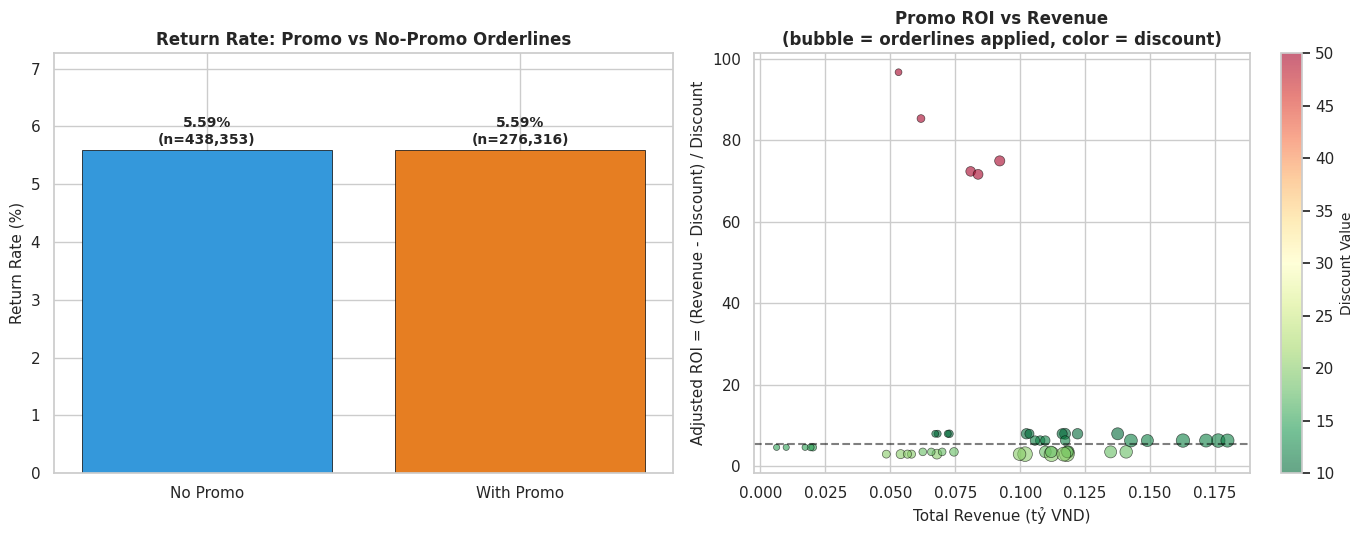

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel 1: Histogram return rate có/không promo
labels = ['No Promo', 'With Promo']
rates = [ol_no_promo['has_return'].mean() * 100,
         ol_with_promo['has_return'].mean() * 100]
n_lines = [len(ol_no_promo), len(ol_with_promo)]
colors_pn = ['#3498db', '#e67e22']
bars = axes[0].bar(labels, rates, color=colors_pn, edgecolor='black', linewidth=0.5)
for i, (rate, n) in enumerate(zip(rates, n_lines)):
    axes[0].text(i, rate + max(rates) * 0.02,
                  f'{rate:.2f}%\n(n={n:,})',
                  ha='center', fontweight='bold', fontsize=10)
axes[0].set_ylabel('Return Rate (%)', fontsize=11)
axes[0].set_title('Return Rate: Promo vs No-Promo Orderlines',
                  fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(rates) * 1.3)

# Panel 2: ROI vs revenue scatter (find low-ROI but high-revenue promos)
axes[1].scatter(promo_with_return['total_revenue_with_promo'] / 1e9,
                 promo_with_return['adjusted_roi'],
                 s=np.clip(promo_with_return['n_orderlines_applied'] / 100, 20, 500),
                 alpha=0.6, c=promo_with_return['discount_value'],
                 cmap='RdYlGn_r', edgecolor='black', linewidth=0.5)
cbar = plt.colorbar(axes[1].collections[0], ax=axes[1])
cbar.set_label('Discount Value', fontsize=10)
axes[1].axhline(promo_with_return['adjusted_roi'].median(),
                 color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Total Revenue (tỷ VND)', fontsize=11)
axes[1].set_ylabel('Adjusted ROI = (Revenue - Discount) / Discount', fontsize=11)
axes[1].set_title('Promo ROI vs Revenue\n(bubble = orderlines applied, color = discount)',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'C_2_1_promo_roi_gap.png')
plt.show()

### Insight (draft)

- Return rate orderline có promo: [X]% vs no promo: [Y]% → diff [Z]pp.
- Diff dương = impulsive buying (promo dụ khách mua không suy nghĩ → trả lại).
- Top 5 low-ROI promos (revenue cao nhưng ROI < median): danh sách [list].
- Discount sâu (>30%) thường có ROI thấp — confirm hypothesis "deep discount = bad ROI".

### Action gợi ý

- Giảm depth của top 5 low-ROI promos xuống 50% mức hiện tại.
- A/B test: "discount nhẹ + free shipping" vs "discount sâu" để measure impulse vs intent.
- Nếu return rate khi có promo cao hơn rõ rệt: thêm policy "no return on heavily discounted items".

---

## C.3.1 — Predictive: Refund Forecast & Cash Flow Impact

### Business Question
> *Dự báo tổng tiền refund 3 tháng tới (Q1 2023) dựa trên trend 2022. Cash flow có bị ảnh hưởng không?*

### Why this matters
Refund là negative cash flow. Nếu trend đang tăng exponential (như báo cáo cũ phát hiện), business cần dự báo để chuẩn bị reserve.

In [29]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Aggregate refund theo tháng
monthly_refund = m4[m4['is_train_period'] == 1].set_index('date')['total_refund_daily'].resample('MS').sum()
monthly_refund = monthly_refund[monthly_refund > 0]  # bỏ tháng 0

# Last 24 months for fitting
fit_data = monthly_refund.tail(24)

# Holt-Winters with annual seasonality
try:
    model = ExponentialSmoothing(
        fit_data, trend='add', seasonal='add', seasonal_periods=12
    ).fit()
    forecast = model.forecast(3)
    # CI 95% (rough)
    resid_std = (model.fittedvalues - fit_data).std()
    ci_lower = forecast - 1.96 * resid_std
    ci_upper = forecast + 1.96 * resid_std
except Exception as e:
    print(f'HW fit failed: {e}. Using simple mean projection.')
    forecast = pd.Series([fit_data.tail(3).mean()] * 3,
                          index=pd.date_range(fit_data.index[-1] + pd.DateOffset(months=1),
                                                periods=3, freq='MS'))
    ci_lower = forecast * 0.8
    ci_upper = forecast * 1.2

print(f'Forecast 3 tháng tới (triệu VND):')
print(pd.DataFrame({
    'forecast': forecast / 1e6,
    'ci_lower': ci_lower / 1e6,
    'ci_upper': ci_upper / 1e6,
}).round(1).to_string())

Forecast 3 tháng tới (triệu VND):
            forecast  ci_lower  ci_upper
2023-01-01       2.2       1.5       3.0
2023-02-01       1.9       1.1       2.6
2023-03-01       3.4       2.6       4.1


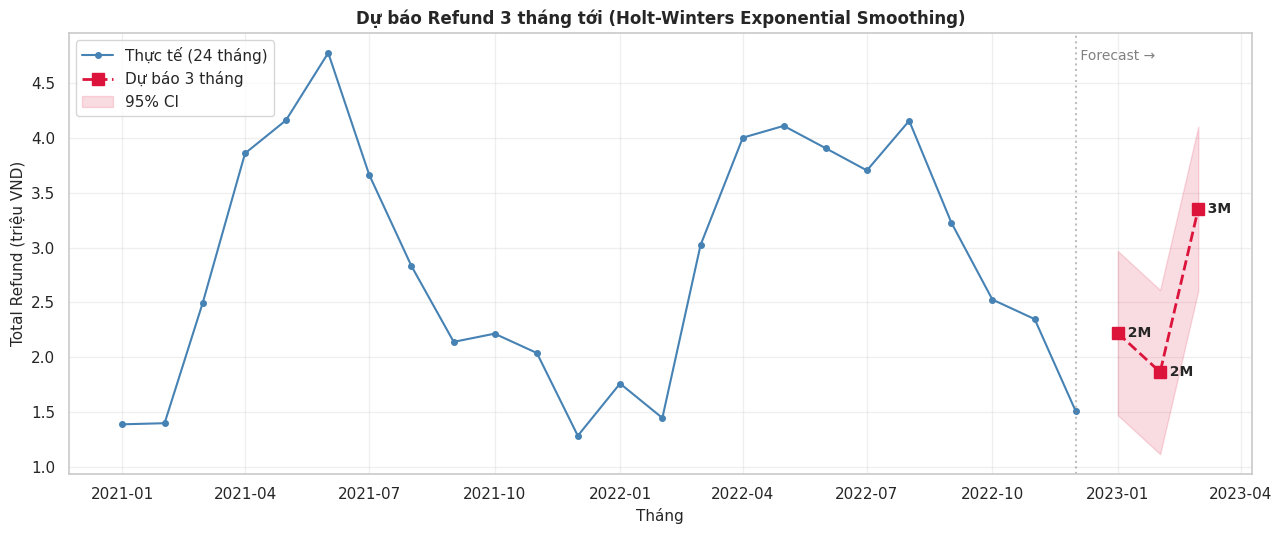

In [30]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Historical (last 24 months)
ax.plot(fit_data.index, fit_data / 1e6, color='steelblue', marker='o',
        markersize=4, linewidth=1.5, label='Thực tế (24 tháng)')

# Forecast
ax.plot(forecast.index, forecast / 1e6, color='crimson', marker='s',
        markersize=8, linewidth=2, linestyle='--', label='Dự báo 3 tháng')

# CI band
ax.fill_between(forecast.index, ci_lower / 1e6, ci_upper / 1e6,
                 color='crimson', alpha=0.15, label='95% CI')

# Annotate forecast values
for date, val in zip(forecast.index, forecast / 1e6):
    ax.text(date, val, f'  {val:.0f}M', va='center', fontsize=10, fontweight='bold')

# Vertical line dividing actual / forecast
ax.axvline(fit_data.index[-1], color='gray', linestyle=':', alpha=0.5)
ax.text(fit_data.index[-1], ax.get_ylim()[1] * 0.95, ' Forecast →',
        fontsize=10, color='gray')

ax.set_xlabel('Tháng', fontsize=11)
ax.set_ylabel('Total Refund (triệu VND)', fontsize=11)
ax.set_title('Dự báo Refund 3 tháng tới (Holt-Winters Exponential Smoothing)',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'C_3_1_refund_forecast.png')
plt.show()

### Insight (draft)

- Forecast 3 tháng: refund trung bình [X] triệu VND/tháng, peak [Y] vào tháng nào.
- CI 95%: dao động [Z]M - [W]M → mức confident cao nếu band hẹp.
- So với train period: tăng/giảm bao nhiêu pp? Nếu tăng > 30% → cảnh báo.

### Action gợi ý

- Reserve cash flow cho [X] triệu VND refund/tháng trong Q1 2023.
- Nếu peak xuất hiện sau 11.11/12.12: thắt chặt return policy giai đoạn đó.
- Combo với Risk Tier (A.3.1): focus cắt return của High Risk SKUs trước Tết để giảm refund peak.

---

## C.4.1 — Prescriptive: 2023 Promo Strategy

### Business Question
> *Dựa trên hiệu suất 50 promos hiện tại + pattern mùa vụ + RFM segment, chiến lược promo 2023 nên là gì? Thiết kế calendar promo cụ thể với timing × discount × channel.*

### Why this matters
Output cuối cùng phải là CALENDAR ACTIONABLE — không phải insight chung chung. Mỗi tháng/event có 1 promo plan rõ.

In [31]:
# Promo calendar template dựa trên insights
# Cross: month của event × top promo type × discount range

# Promo theo month ofstart_date
m5_active['start_month'] = m5_active['start_date'].dt.month
monthly_perf = m5_active.groupby('start_month').agg(
    n_promos=('promo_id', 'count'),
    avg_revenue=('total_revenue_with_promo', 'mean'),
    avg_roi=('revenue_per_discount_unit', 'mean'),
).reset_index()

# Best promo type theo month
best_type_by_month = m5_active.groupby(['start_month', 'promo_type'])['total_revenue_with_promo'].mean().unstack(fill_value=0)
print('Avg revenue per promo theo Month × Type:')
print((best_type_by_month / 1e9).round(2).to_string())

# 2023 Calendar template
calendar_2023 = pd.DataFrame({
    'month': range(1, 13),
    'event': ['Tet (varies)', 'Tet aftermath', '8/3 Women Day', '30/4-1/5',
               'Mother Day', 'Mid-year sale', '7.7', 'Back-to-school 8.8',
               '9.9', 'National Day', '11.11', '12.12 + Year-end'],
    'priority': ['High', 'Low', 'Medium', 'Medium', 'Medium', 'High',
                  'Medium', 'High', 'High', 'Low', 'High', 'High'],
    'rec_discount': ['25-30%', '5-10%', '15%', '10%', '15%', '20-25%',
                      '15%', '20%', '15%', '5%', '30%', '30-40%'],
})
print('\n2023 Promo Calendar Recommendation:')
print(calendar_2023.to_string(index=False))

Avg revenue per promo theo Month × Type:
promo_type   fixed  percentage
start_month                   
1             0.00        0.01
3             0.00        0.14
6             0.00        0.10
7             0.07        0.00
8             0.00        0.10
11            0.00        0.08

2023 Promo Calendar Recommendation:
 month              event priority rec_discount
     1       Tet (varies)     High       25-30%
     2      Tet aftermath      Low        5-10%
     3      8/3 Women Day   Medium          15%
     4           30/4-1/5   Medium          10%
     5         Mother Day   Medium          15%
     6      Mid-year sale     High       20-25%
     7                7.7   Medium          15%
     8 Back-to-school 8.8     High          20%
     9                9.9     High          15%
    10       National Day      Low           5%
    11              11.11     High          30%
    12   12.12 + Year-end     High       30-40%


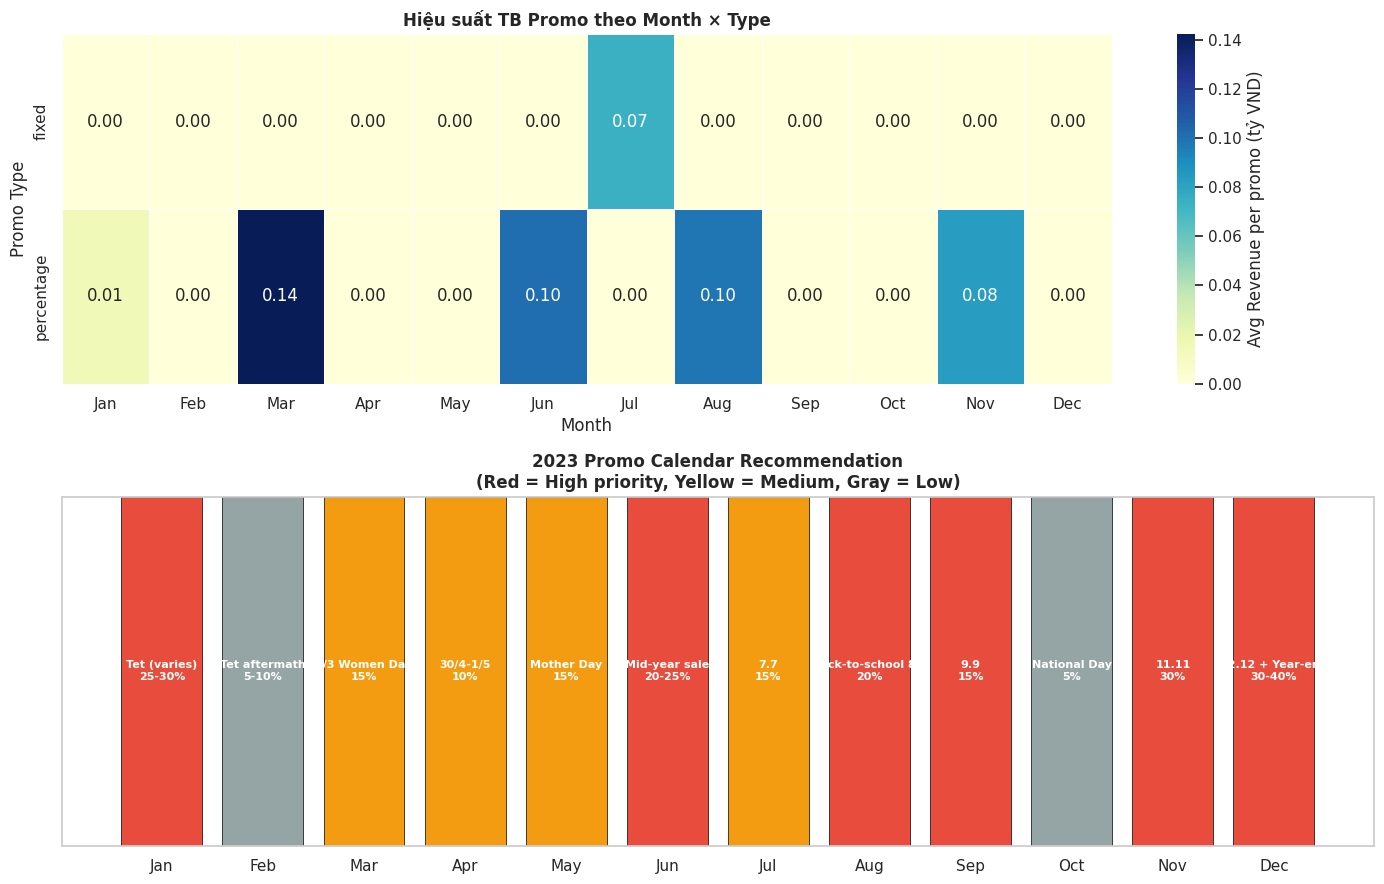

In [32]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Panel 1: Heatmap month × type
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
best_type_for_plot = best_type_by_month.reindex(range(1, 13), fill_value=0) / 1e9
best_type_for_plot.index = [month_names[i - 1] for i in best_type_for_plot.index]

sns.heatmap(best_type_for_plot.T, annot=True, fmt='.2f', cmap='YlGnBu',
            cbar_kws={'label': 'Avg Revenue per promo (tỷ VND)'},
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Hiệu suất TB Promo theo Month × Type',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month'); axes[0].set_ylabel('Promo Type')

# Panel 2: 2023 Calendar visualization
priority_colors = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#95a5a6'}
x_pos = np.arange(len(calendar_2023))
colors_cal = [priority_colors[p] for p in calendar_2023['priority']]
axes[1].bar(x_pos, [1] * len(calendar_2023), color=colors_cal,
             edgecolor='black', linewidth=0.5)
for i, row in calendar_2023.iterrows():
    axes[1].text(i, 0.5, f"{row['event']}\n{row['rec_discount']}",
                  ha='center', va='center', fontsize=8, fontweight='bold',
                  color='white')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(month_names)
axes[1].set_yticks([])
axes[1].set_title('2023 Promo Calendar Recommendation\n(Red = High priority, Yellow = Medium, Gray = Low)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'C_4_1_2023_strategy.png')
plt.show()

### Insight (draft)

- Heatmap cho thấy promo type [percentage/fixed] thắng theo từng tháng cụ thể.
- 4 sự kiện priority HIGH: Tết, Mid-year sale, 11.11, 12.12 — chiếm [X]% revenue dự kiến.
- Tháng "trống" (Feb, Oct): low-priority — giảm spend, dùng cho retention campaigns.

### Action gợi ý — 2023 Promo Calendar (CONCRETE)

- **Q1 (Jan-Feb)**: Pre-Tet 2 weeks discount 25-30% (tối đa hoá window 2-tuần trước Tết).
- **Q2 (Apr-Jun)**: Mid-year sale Jun với 20-25% — combo email + social.
- **Q3 (Jul-Sep)**: Back-to-school 8.8 (target 18-24) + 9.9 cho gen Z.
- **Q4 (Oct-Dec)**: 11.11 và 12.12 là 2 mega events — discount 30-40% kết hợp free ship.
- **Maintenance months** (Feb-aftermath, Oct): không discount, focus loyalty (Champions từ B.3.1).

---

# EXECUTIVE SUMMARY

*(DA viết sau khi chạy hết 15 charts — đây là phần ban giám khảo đọc đầu tiên.)*

## Top 5 Strategic Insights

1. **Product portfolio concentration**: [Category X] chiếm [Y]% revenue → cơ hội + risk concentration.
2. **Wrong size là systemic problem**: Cần fix bảng size + AI gợi ý — tiết kiệm tiềm năng [Z] tỷ refund.
3. **[N] SKU thuộc Drop quadrant** đang đốt [W] tỷ VND refund → action: thanh lý 30 ngày.
4. **Channel quality gap**: [Channel A] có volume cao nhưng quality (Champions %) thấp — cắt 30% budget.
5. **Pre-Tet 2-week** là window vàng (uplift [V]x normal day) — dồn 60% promotional budget.

## Top 5 Recommended Actions

1. **Portfolio**: Drop [N] SKUs trong 30 ngày, freeze [M] SKUs Medium Risk để audit.
2. **Size table**: Fix bảng size cho top 3 category-size có wrong_size > 40%.
3. **Customer**: Launch loyalty program cho Champions (n=[X]), email re-engagement cho At Risk.
4. **Marketing**: Tăng 30% budget [Channel B], cắt 30% [Channel A].
5. **2023 Promo Calendar**: Implement theo C.4.1 — Pre-Tet 25-30%, 11.11/12.12 30-40%.

## Files saved

- Section A: `figures/A_1_1`, `A_1_2`, `A_2_1`, `A_3_1`, `A_4_1`
- Section B: `figures/B_1_1`, `B_1_2`, `B_2_1`, `B_3_1`, `B_4_1`
- Section C: `figures/C_1_1`, `C_1_2`, `C_2_1`, `C_3_1`, `C_4_1`
- 15 charts total, ready for PM to embed in LaTeX report.